# 第六讲：多模态、CLIP 与文本编码器


## 本节课学习目标

1. 能用通俗语言解释“共享表示空间”是什么。
2. 能看懂 CLIP 的图文对比学习：为什么对角线要亮，非对角线要暗。
3. 能从零实现一个最小 toy CLIP，并解释 loss、相似度矩阵、zero-shot、检索结果。
4. 能使用预训练 OpenAI CLIP 做 zero-shot 分类、图文检索、图片到文本匹配、多选式 VQA。
5. 能说出 CLIP 的边界：它更像“匹配器”，不是万能视觉推理器。
6. 能区分 CLIP 编码器和 T5 编码器：一个擅长“配不配”，一个擅长“读得细”。
7. 能理解 ImageBind 为什么是 CLIP 思路的自然扩展。
8. 能用 `latent`、`token`、`attention` 解释 DiT / Wan 为什么适合视频生成。
9. 能用 `alignment` 和 `fidelity` 评价生成模型结果。

## 阅读导航：本 notebook 怎么读

本 notebook 按“先直觉、再原理、再代码、再真实 demo、最后作业”的顺序组织。建议按下面编号阅读：

| 序号 | 章节 | 重点问题 | 关键产出 |
|---:|---|---|---|
| 0 | 依赖、设备与课程路线图 | 这节课要跑哪些模型？需要哪些库？ | 明确环境和本节课主线 |
| 1 | 开场：这些任务是不是同一件事？ | 分类、检索、VQA 能不能都看成相似度比较？ | 建立 CLIP 的直觉 |
| 2 | CLIP / ALIGN / SigLIP 论文思想 | 正确图文对为什么要在对角线上？SigLIP 解决了什么痛点？ | 理解对比学习目标 |
| 3 | 从零实现 toy CLIP | 最小 image encoder、text encoder 和 contrastive loss 怎么工作？ | 看到 loss、热力图、检索结果 |
| 4 | 预训练 OpenAI CLIP 真实 demo | prompt 会不会影响结果？CLIP 能做哪些任务？ | zero-shot、检索、image-to-text、多选式 VQA |
| 5 | CLIP 的局限 | CLIP 是在理解图像，还是在做高级匹配？ | 认识计数、空间关系、拒答等边界 |
| 6 | CLIPText 和 T5 encoder | 两个 encoder 都叫 encoder，为什么分工不同？ | 理解短 prompt vs 长 prompt |
| 7 | ImageBind | 多模态共享空间能不能扩展到图像、文本、声音、深度等？ | 理解 CLIP 思想的扩展 |
| 8 | DiT / Wan 与视频生成 | latent、token、attention 在生成模型里分别解决什么？ | 从“比较”走向“生成” |
| 9 | 课堂小测 | 10 个问题检查有没有听懂 | 用 6 个关键词复述主线 |
| 10 | 小结 | 用 10 句话收住全课 | 形成完整知识框架 |
| 11 | 课程作业 | 用 OpenCLIP 在 Flickr8k 上训练图文匹配模型 | 提交训练、验证、retrieval 和错误分析 |

### 本 notebook 的主线

```text
CLIP：
图片和文字能不能放到同一个空间里比较？

ALIGN / SigLIP：
大规模图文对比学习怎么训练更稳定、更不依赖超大 batch？

toy CLIP：
从零写一个最小模型，看 loss 和相似度矩阵怎么变化。

真实 CLIP：
用预训练 OpenAI CLIP 做 zero-shot、检索、image-to-text、多选式 VQA。

生成模型：
从“图文匹配”走向“文本控制生成”，理解 T5、DiT、Wan、ImageBind。
```


## 本 notebook 使用的论文原图说明

下面各章节中插入的论文图，来自相应论文 PDF 的原图裁剪，保留图号或图注

In [1]:
# ------------------------------
# 这段代码做什么：
# 1. 导入本节课需要的依赖
# 2. 固定随机种子，保证结果更稳定
# 3. 配置是否运行 ImageBind 扩展
# ------------------------------
from pathlib import Path
import math
import random
import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets
from PIL import Image, ImageDraw
from transformers import CLIPModel, CLIPProcessor

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

device = "cuda" if torch.cuda.is_available() else "cpu"
RUN_IMAGEBIND = False

print("device =", device)
print("RUN_IMAGEBIND =", RUN_IMAGEBIND)

device = cpu
RUN_IMAGEBIND = False


## Part 1. 开场：这些任务是不是同一件事？

先不要讲定义。先给大家三个任务：

1. 给一张图分类：cat / dog / truck。
2. 用一句话找图片：`a red car on the street`。
3. 给图片做多选题：`the answer is cat / dog / bird`。

**开放问题 1：**

> 这三个任务看起来不一样，它们有没有可能本质上是同一件事？

两人一组讨论 2 分钟。收几个答案后再给出本节课的核心说法：

> 它们都可以看成“图片向量”和“文字向量”的相似度比较。

### 课堂投票 1：CLIP 更像什么？

先不要看答案，凭直觉选一个：

- A. 分类器
- B. 搜索引擎
- C. 翻译器
- D. 生成器

等会儿跑完 demo 后再回来修正：CLIP 的核心不是“生成”，也不是“翻译”，而是把图片和文字都变成向量，然后做相似度比较。

### 课堂投票 2：prompt 会不会影响结果？

同一张图片，用下面两个文本候选，CLIP 的结果会不会一样？

```text
cat
a photo of a cat
```

请先投票：

- A. 完全一样
- B. 可能会不一样
- C. 只有模型很差时才会不一样

提示：prompt 不是装饰。它会改变文本向量，所以可能改变排序。

### 课堂任务单：先把任务翻译成“相似度比较”

给大家 6 分钟完成下面这张表。不要求马上答对，重点是训练“把任务改写成比较问题”的能力。

| 原任务 | 可以怎么改写成相似度比较 | 候选文本从哪里来 |
|---|---|---|
| 图片分类 | 图片 vs 类别 prompt | 类别名 |
| 文本搜图 | 查询文本 vs 图片库 | 用户输入 |
| 图片搜描述 | 图片 vs 描述库 | 标题/标签/候选说明 |
| 多选式 VQA | 图片 vs 候选答案 | 选项 |
| 内容审核 | 图片 vs 风险描述 | 审核规则 |
| 商品检索 | 商品图 vs 用户搜索词 | 商品标题/类目 |

讨论问题：

> 如果一个任务可以被改写成“图片和文本谁更像”，它就一定适合用 CLIP 吗？

这会自然引出后面的边界：能排序，不代表能可靠推理。

### 人肉 CLIP demo：先自己配对

先不要看答案。看左边 4 张图和右边 4 段文字，判断哪张图应该配哪句话。

<img src="images/lesson6_multimodal/human_clip_options.png" width="980">

如果把这 4 个图文对按同样顺序排列：

| | text 1: `a red circle` | text 2: `a blue square` | text 3: `a green triangle` | text 4: `a yellow diamond` |
|---|---|---|---|---|
| image 1: 红色圆形 | 高 | 低 | 低 | 低 |
| image 2: 蓝色方形 | 低 | 高 | 低 | 低 |
| image 3: 绿色三角形 | 低 | 低 | 高 | 低 |
| image 4: 黄色菱形 | 低 | 低 | 低 | 高 |

课堂问题：

> 哪些格子应该分数最高？为什么把图片和文字按同样语义顺序排列时，正确答案刚好在对角线上？

这一步的目的不是讲数学，而是让大家先看到 CLIP 训练目标的形状：**正确配对要亮，错误配对要暗。**

### 4x4 相似度矩阵怎么变成 loss

1. 如果只从 image 1 看，它要在 4 个 text 里选谁？
2. 如果只从 text 1 看，它要在 4 张 image 里选谁？
3. 为什么 CLIP 的 loss 要算两个方向？


/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_50115/3965739068.py:30: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_50115/3965739068.py:30: UserWarning: Glyph 24819 (\N{CJK UNIFIED IDEOGRAPH-60F3}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_50115/3965739068.py:30: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_50115/3965739068.py:30: UserWarning: Glyph 20917 (\N{CJK UNIFIED IDEOGRAPH-51B5}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_50115/3965739068.py:30: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/i

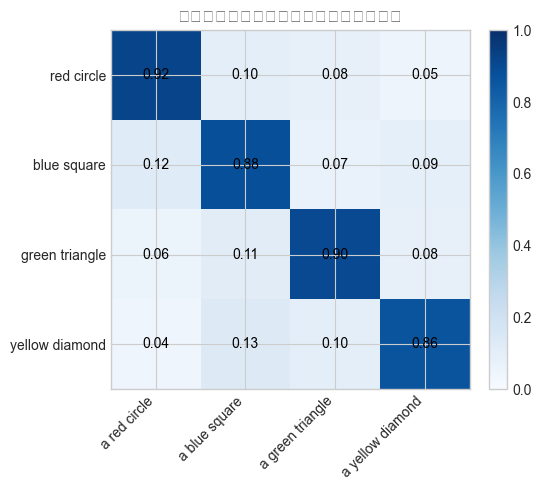

In [2]:
# ------------------------------
# 这段代码做什么：
# 1. 手写一个 4x4 图文相似度矩阵
# 2. 用热力图看“对角线应该亮”
# ------------------------------
import numpy as np
import matplotlib.pyplot as plt

sim = np.array([
    [0.92, 0.10, 0.08, 0.05],
    [0.12, 0.88, 0.07, 0.09],
    [0.06, 0.11, 0.90, 0.08],
    [0.04, 0.13, 0.10, 0.86],
])

images = ["red circle", "blue square", "green triangle", "yellow diamond"]
texts = ["a red circle", "a blue square", "a green triangle", "a yellow diamond"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim, vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(len(texts)))
ax.set_xticklabels(texts, rotation=45, ha="right")
ax.set_yticks(range(len(images)))
ax.set_yticklabels(images)
ax.set_title("理想情况下：正确图文对在对角线上更亮")
for i in range(len(images)):
    for j in range(len(texts)):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 诊断问题：非对角线为什么会亮？

如果热力图里非对角线也变亮，通常不是“模型完全错了”，而是说明候选项之间有相似语义。

例如：

- `red circle` 和 `red square` 都有 `red`；
- `blue square` 和 `blue triangle` 都有 `blue`；
- `green triangle` 和 `green object` 可能共享一部分语义。

所以 CLIP 的排序不是“只认一个关键词”，而是综合判断整体相似度。  
这也解释了为什么它有时能泛化，有时又会在细粒度属性上混淆。

## Part 2. CLIP 论文思想：图文对比学习



- 论文：Radford et al., 2021, [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020)
- 关键结论：用大量图文对训练后，模型可以用自然语言描述视觉概念，并迁移到很多分类任务。
- 课堂翻译：图片和文字被放进同一个空间后，分类可以变成“拿图片去找最像的一句话”。

1. CLIP模型结构

CLIP 的关键思想是通过训练两个编码器（图像和文本编码器）使得相对应的图像和文本在同一潜在空间中尽可能接近，而不相关的图像和文本尽可能远离。文本经过Text Encoder得到文本的向量表示，图片经过Image Encoder得到图片的向量表示，分别通过线性投射层，投射到共同的多模态线性空间里，即一个共享的公共子空间，在这个线性空间里面， 通过对比学习的方法，最大化正确图像-文本对在该子空间内的相似度，并最小化错误图像-文本对的相似度，从而优化出一个能够有效捕捉跨模态语义关系的公共子空间。拉近配对文本的图片和向量，而让不配对的文本和图片向量尽可能地远。CLIP 是一个基于对比学习的框架，通常包括以下两部分：图像编码器（Image Encoder）：图像编码器通常使用卷积神经网络（CNN）或视觉Transformer（ViT）作为基础网络架构，负责提取图像的特征表示。图像编码器的输出是图像的潜在空间表示。文本编码器（Text Encoder）：文本编码器通常使用Transformer架构，负责将文本（如描述图像的自然语言）转换为相应的潜在表示。文本编码器的输出是文本的潜在空间表示。

CLIP 一个最重要的能力就是可以实现 zero-shot 分类，在之前的分类模型中（如ResNet），训练1000个类别，预测就是这1000个类别的概率，无法拓展，新增类别还得重新训练重新标注太麻烦了。CLIP就把图像数据做成预训练模型，直接实现零样本分类，有新的类别来了，也不需要进行再次训练，利用文本的监督信号训练一个迁移能力强的视觉模型。具体步骤如下：加载模型和准备数据：加载预训练的 CLIP 模型的图像和文本特征编码器，准备要分类的图像和自然语言描述的类别标签，如 A photo of a {object}（将其中的 object 替换成所有的类别标签，如 dog）。编码图像和文本：使用 CLIP 模型的图像和文本特征编码器将图像和标签文本编码为向量。计算相似度并分类：计算图像向量与所有标签文本嵌入之间的余弦相似度，选择相似度最高的标签作为结果。



### 论文原图：CLIP 方法图和 zero-shot 效果

**CLIP Figure 1：方法总览**

<img src="images/lesson6_multimodal/paper_originals/clip_fig1_method.png" width="980">

这张原图可以分成两半看：左边是**训练**，右边是**zero-shot 推理**。

### 1. 训练阶段：让配对图文靠近，不配对图文远离

CLIP 训练时拿到的是大量“图片-文字”配对数据。比如一张狗的图片，旁边配一句描述这张图片的文字。模型做两件事：

- 图片经过图像编码器，变成一个向量。
- 文字经过文本编码器，也变成一个向量。
- 如果图片和文字本来就是一对，它们的向量应该更像。
- 如果图片和文字不是一对，它们的向量应该不像。

可以把它理解成一个“配对游戏”：正确配对的图文要站得近，错误配对的图文要分开。

### 2. 相似度矩阵：一批数据一起比较

假设一个 batch 里有 64 对图文，那么会得到：

```text
visual_embedding: [64, embedding_size]
text_embedding:   [64, embedding_size]
```

把 64 个图片向量和 64 个文本向量两两计算相似度，就会得到一个 `[64, 64]` 的矩阵。

- 第 1 行：第 1 张图片和 64 段文字分别有多像。
- 第 2 行：第 2 张图片和 64 段文字分别有多像。
- 对角线位置：原本配对的图片和文字。
- 非对角线位置：不配对的图片和文字。

训练目标很直观：让对角线上的分数变大，让其它位置的分数变小。这样一来，模型就学会了把图片和语言放进同一个表示空间里。

从分类角度看，每一行都可以当成一个 64 分类问题。第 1 张图应该匹配第 1 段文字，第 2 张图应该匹配第 2 段文字，所以标签就是：

```text
[0, 1, 2, 3, ..., 63]
```

这就是 CLIP 的对比学习：不用人工给每张图标一个固定类别，而是利用图文配对关系来学习。

**论文证据：CLIP 原文里的 softmax / cross entropy**

<img src="images/lesson6_multimodal/paper_originals/clip_softmax_loss_excerpt.png" width="720">

这段原文要抓住两个点：

- CLIP 优化的是 **symmetric cross entropy loss**，也就是图找文、文找图两个方向都算交叉熵。
- 原文还提到 temperature 参数会控制进入 softmax 的 logits 范围，所以 CLIP 这里确实是 softmax 式的对比学习。

简而言之：CLIP 在一个 batch 里把正确图文对当成答案，把其它组合当成干扰项，然后用交叉熵让模型把正确答案选出来。



### 3. 测试阶段：把类别写成 prompt，再和图片比较

CLIP 做分类时，不需要固定的最后一层分类器。我们只要把候选类别写成文字，让文本编码器把它们变成向量，再和图片向量比相似度。

例如要判断一张图片是猫、狗还是鸟，可以写成：

```text
A photo of a cat.
A photo of a dog.
A photo of a bird.
```

然后做三次比较：

- 图片向量 vs `A photo of a cat.`
- 图片向量 vs `A photo of a dog.`
- 图片向量 vs `A photo of a bird.`

哪个文本和图片最像，就预测成哪个类别。

这也是 prompt engineering 的基本原因：预训练时模型看到的大多是自然语言句子，所以推理时写成 `A photo of a ...` 往往比只写 `cat`、`dog`、`bird` 更稳。

### 4. 为什么这比普通分类器灵活？

传统分类网络的类别通常是固定的。比如一个 ResNet 最后一层如果是 1000 类，那它就只能在这 1000 类里选。如果想加新类别，常常要改最后一层，还要重新训练或微调。

这里说的“最后一层”，就是常说的**分类头**。它可以理解成一个固定菜单：

```text
图像特征 -> 分类头 -> 1000 个类别分数
```

如果训练时只有 `cat/dog/bird` 三类，分类头就只学会输出这三类的分数。现在突然想加一个新类别 `red panda`，原来的分类头没有这个输出位置，通常就要改分类头，并用带标签的数据重新训练或微调。

CLIP 的做法不一样。它没有把类别固定死在最后一层，而是把类别写成文字，让文本编码器临时生成“类别向量”：

```text
A photo of a cat.       -> 文本向量
A photo of a dog.       -> 文本向量
A photo of a red panda. -> 文本向量
```

这些文本向量就像临时生成的分类头。图片来了以后，只要和这些文本向量比较相似度即可。想换类别，就换 prompt；想增加类别，就多写几个 prompt。模型参数本身不用因为类别数量变化而改掉。

CLIP 不一样。它比较的是“图片”和“文字”的相似度，所以类别数量和类别内容都可以临时指定：

- 给 2 个 prompt，就是二分类。
- 给 1000 个 prompt，就是 1000 分类。
- 给一些冷门类别，也可以直接尝试。
- 标签不一定是单词，也可以是一整句话。

所以，CLIP 的 zero-shot 分类本质上不是“固定标签分类”，而是“图片和一组文字描述做匹配”。

**CLIP Figure 2：zero-shot 迁移效率**

<img src="images/lesson6_multimodal/paper_originals/clip_fig2_zeroshot_efficiency.png" width="620">

Figure 2 想说明的是：用自然语言监督训练出来的模型，可以更方便地迁移到新任务。因为新任务来了以后，我们不一定要重新设计一个固定分类头，而是可以把新类别写成文字，让模型直接比较图片和这些文字。

课堂问题：

> 这张图为什么能说明“自然语言监督”比固定分类标签更灵活？

提示大家回答时抓住一句话：**固定分类标签像提前写好的菜单，自然语言 prompt 像临时点菜，可以现写、现比、现用。**

### 对比学习公式：只看懂这一版就够了

这一节把 CLIP / ALIGN 的 softmax 对比学习写清楚。核心只有一句话：

> **一个 batch 里，正确图文对在对角线上。loss 的目标就是让对角线变大，非对角线变小。**

### 1. 先把图片和文本变成单位向量

第 `i` 张图片经过图像编码器：

$$
v_i = \frac{f_I(x_i)}{\|f_I(x_i)\|}
$$

第 `j` 段文本经过文本编码器：

$$
t_j = \frac{f_T(y_j)}{\|f_T(y_j)\|}
$$

这里除以向量长度，是为了让向量先归一化。归一化后，两个向量的内积就可以看成余弦相似度：越大，说明越像。

### 2. 再得到图文相似度矩阵

把第 `i` 张图片和第 `j` 段文本做相似度比较。为了避免符号混乱，我们先把没有缩放的相似度叫做 `score`：

$$
score_{ij} = v_i^\top t_j
$$

再乘上缩放系数，得到 softmax 前真正使用的分数：

$$
S_{ij} = \alpha \cdot score_{ij} = \alpha \cdot v_i^\top t_j
$$

其中 $\alpha$ 是一个缩放系数。CLIP 代码里常写成 `logit_scale = exp(tau)`，作用是调节 softmax 前分数的大小。

注意：这一步还不是 softmax。它只是算出一个分数，也叫 `logit`。

**第一步：算相似度**

$$
score_{ij} = v_i^\top t_j
$$

这是图像向量和文本向量的内积。因为前面已经做了归一化，所以它可以看成余弦相似度。

意思是：

```text
第 i 张图片 和 第 j 段文本 有多像
```

**第二步：缩放分数**

$$
\alpha \cdot score_{ij} = \alpha \cdot v_i^\top t_j
$$

这里的 $\alpha$ 只是把相似度分数放大或缩小。这一步得到的是 softmax 的输入，不是 softmax 的输出。

也就是：

$$
S_{ij} = \alpha \cdot score_{ij} = \alpha \cdot v_i^\top t_j
$$

这里的 $S_{ij}$ 是一个 logit。

**第三步：对一整行做 softmax**

比如 image-to-text 方向，对第 $i$ 张图片来说，要在所有文本里选一个。于是对这一整行做 softmax：

$$
p_{ij} = \frac{\exp(S_{ij})}{\sum_k \exp(S_{ik})}
$$

这一步才是 softmax。

所以顺序是：

```text
向量内积 -> 乘 alpha 得到 logits -> 对一整行 logits 做 softmax
```

一句话：$score_{ij}$ 是原始相似度，$S_{ij}$ 是缩放后的 logit，也就是 softmax 前的分数；softmax 是把一整行 logits 变成概率。

如果 batch size 是 `N`，那么 `S` 的形状就是：

```text
S: [N, N]
```

- 第 `i` 行：第 `i` 张图片和所有文本的相似度。
- 第 `j` 列：第 `j` 段文本和所有图片的相似度。
- 对角线 `S_ii`：原本配对的图片和文本。

### 3. image-to-text：让每张图找对文字

先从图片到文本看。对第 `i` 张图片来说，它要在 `N` 段文本里选出正确的 `t_i`。
这一步才会对第 `i` 行的所有分数做 softmax：

$$
L_{i2t} = -\frac{1}{N}\sum_i \log \frac{\exp(S_{ii})}{\sum_j \exp(S_{ij})}
$$

通俗说：

```text
image_i 应该在 text_1, text_2, ..., text_N 里面选中 text_i。
```

这就是为什么说 softmax 对比学习像选择题：每一行都在做一次 `N` 选 1。

### 4. text-to-image：让每句话也找对图片

再从文本到图片看。对第 `i` 段文本来说，它要在 `N` 张图片里选出正确的 `v_i`。

$$
L_{t2i} = -\frac{1}{N}\sum_i \log \frac{\exp(S_{ii})}{\sum_j \exp(S_{ji})}
$$

通俗说：

```text
text_i 应该在 image_1, image_2, ..., image_N 里面选中 image_i。
```

### 5. 总 loss：两个方向加在一起

到这里其实已经够了：CLIP 和 ALIGN 都会同时训练两个方向。

$$
L = \frac{1}{2}\left(L_{i2t} + L_{t2i}\right)
$$

这句话的意思很简单：

- 一半训练“图片找文字”。
- 一半训练“文字找图片”。
- 两个方向一起训，图像空间和文本空间才会互相对齐。

### 6. 为什么代码里会写成 `CE(S, labels)`？

这一段不是新的理论，只是在解释代码怎么实现上面的公式。CLIP 论文 Figure 3 里正好给了 Numpy 风格伪代码：

<img src="images/lesson6_multimodal/paper_originals/clip_fig3_pseudocode_loss.png" width="720">

这张图里最关键的是最后几行：

```text
labels = np.arange(n)
loss_i = cross_entropy_loss(logits, labels, axis=0)
loss_t = cross_entropy_loss(logits, labels, axis=1)
loss   = (loss_i + loss_t)/2
```

它和前面的数学公式是一回事：`logits` 就是相似度矩阵 $S$，`labels=np.arange(n)` 就是 `[0,1,2,...,N-1]`。`loss_i` 和 `loss_t` 分别沿两个方向算交叉熵，最后取平均。不同代码库对 `axis=0/axis=1` 的写法可能不同，只要抓住一点：**一个方向是图片找文字，另一个方向是文字找图片。**

假设 batch size 是 3，相似度矩阵是：

```text
          text0   text1   text2
image0    S00     S01     S02
image1    S10     S11     S12
image2    S20     S21     S22
```

正确图文对在对角线上：

```text
image0 -> text0
image1 -> text1
image2 -> text2
```

所以标签就是：

```text
labels = [0, 1, 2]
```

`CE(S, labels)` 会对 `S` 的每一行做 softmax。也就是：

```text
第 0 行：image0 在 text0/text1/text2 里选 text0
第 1 行：image1 在 text0/text1/text2 里选 text1
第 2 行：image2 在 text0/text1/text2 里选 text2
```

所以：

$$
CE(S, labels) = L_{i2t}
$$

如果把矩阵转置成 $S^\top$，行和列就换过来了。此时每一行变成“一段文本和所有图片的相似度”。所以：

```text
CE(S^T, labels)：每句话在所有图片里选自己的图片
```

也就是：

$$
CE(S^\top, labels) = L_{t2i}
$$

因此，代码里常见的写法就是：

$$
L = \frac{1}{2}\left[CE(S, labels) + CE(S^\top, labels)\right]
$$

这一行代码只是把“图片找文字”和“文字找图片”两个 loss 合在一起写了。

课堂问题：

> 如果一个 batch 里面有两张很像的图，非对角线也变亮，会发生什么？

引导回答：模型会更难区分这两个样本，loss 可能变大；但这也提供了更细的训练信号，逼模型学习更具体的差别。

### 论文原图：ALIGN 和 SigLIP

**ALIGN Figure 1：大规模噪声图文对训练**

<img src="images/lesson6_multimodal/paper_originals/align_fig1_method.png" width="980">

CLIP 证明了“图文配对训练”有效。ALIGN 接着问了一个更现实的问题：

> 如果不用精心清洗的数据，而是直接使用互联网上大量图片和网页文字，模型还能学好吗？

这张图重点看两点：

- **数据来源更野生**：图片旁边的文字可能来自网页标题、alt-text、文件名、周围文本，不一定是人工写好的标准描述。
- **规模非常大**：单条图文对可能不完美，但大量数据里会反复出现稳定规律，比如“狗-狗的图片”“汽车-街道图片”“食物-餐盘图片”。

可以把 ALIGN 总结成一句话：

> **别指望每一条网络图文对都干净，但如果数据足够大，模型仍然能从大量重复出现的线索里学到图文对齐。**

**ALIGN Figure 2：真实网络图文对的噪声**

<img src="images/lesson6_multimodal/paper_originals/align_fig2_noisy_pairs.png" width="920">

这张图左边的小例子，是从 ALIGN 训练数据里随机抽出来的“图片-文字”配对。它想告诉我们：真实网络数据并不像教科书数据那样整齐。

可以带大家逐个看：

- 有的文字像文件名，例如 `file london barge race 2 jpg`。
- 有的文字只是日期，例如 `57 29 june 2010`，几乎没有描述图片内容。
- 有的文字像网页标题或地点名，例如 `st oswalds way and shops`。

这些文本不一定错得离谱，但它们通常不够干净、不够完整，也不一定直接描述图片主体。这就是论文标题里说的 **noisy text supervision**：监督信号来自文本，但文本是有噪声的。

**论文证据：ALIGN 原文里的 normalized softmax loss**

<img src="images/lesson6_multimodal/paper_originals/align_softmax_loss_excerpt.png" width="760">

这张截图可以直接用来回答“ALIGN 是否用了 softmax”：原文明确说图像编码器和文本编码器通过 **normalized softmax loss** 优化，并且把匹配图文对当成正样本，把 batch 里其它随机组合当成负样本。

右边的两个公式说明 ALIGN 仍然使用 CLIP 风格的图文对比学习，只是数据更大、更杂。

第一个方向是 `image-to-text`：

```text
给定第 i 张图片，在这一批 N 段文本里，找出最匹配的那一段。
```

第二个方向是 `text-to-image`：

```text
给定第 i 段文本，在这一批 N 张图片里，找出最匹配的那一张。
```

公式里的符号可以这样读：

- `x_i`：第 `i` 张图片的向量。
- `y_j`：第 `j` 段文本的向量。
- `x_i^T y_j`：图片和文本的相似度。
- `N`：batch size，也就是一批里有多少对图文。
- `σ`：温度系数，用来调节分数有多“尖锐”。

所以这张图要合起来看：左边告诉你“数据很脏”，右边告诉你“训练目标仍然是让正确图文更接近、错误图文更远”。ALIGN 的关键判断是：噪声会带来问题，但足够大的规模可以抵消一部分噪声。

课堂问题：

> 如果一部分图文对是错的，为什么模型没有完全学坏？

可以引导大家这样回答：

- 错误样本的方向比较乱，不会总是把模型往同一个错误方向推。
- 正确或大致正确的图文关系会反复出现，模型更容易学到这些稳定规律。
- 规模不是魔法，噪声仍然会伤害模型；只是当数据非常多时，稳定信号可能盖过一部分随机噪声。



### 先说 CLIP 的痛点：为什么还要有 SigLIP？

前面 CLIP / ALIGN 的核心做法是 **softmax 对比学习**。  
它像是在做一个“选择题”：

```text
给一张图片，在 batch 里的很多文本中选出正确文本。
```

这个目标很有效，但有一个明显痛点：

> **它很依赖 batch 内部的负例。**

也就是说，CLIP 希望一个 batch 里有足够多的“错误图文组合”，这样模型才知道哪些图文对不该匹配。

---

### CLIP 的痛点 1：batch size 太小，负例不够

如果 batch 很小，比如只有 8 对图文，那么每张图只能看到 7 个文本负例。

这会导致：

- 对比信号不够强；
- 模型更容易过拟合；
- 训练稳定性差；
- 需要更大的 batch，也就更吃显存。

所以 CLIP 这类 softmax 对比学习通常很喜欢大 batch。

---

### CLIP 的痛点 2：大 batch 会带来显存和通信压力

如果 batch 变大，比如 4096 或 8192，确实负例更多了。  
但代价也很明显：

- 相似度矩阵变大；
- softmax 计算更重；
- 多卡训练时通信开销更高；
- 显存占用上升。

所以 CLIP 的训练目标本身有一个矛盾：

> **它需要大 batch 提供足够负例，但大 batch 又让训练更贵。**

---

### CLIP 的痛点 3：softmax 让样本互相竞争

CLIP 的 softmax loss 会让一张图片在整批文本里“选一个正确答案”。  
这意味着同一行里的所有候选文本会互相竞争。

可以先这样理解：

```text
image_i 必须在 text_1, text_2, ..., text_N 里选中 text_i。
```

这很像一个单选题。  
但如果 batch 不够大，或者 batch 里负例质量不稳定，这个“单选题”的信号就可能不够充分。

---

###  SigLIP能做什么？


SigLIP 主要想解决的就是这个问题：

> **能不能不再依赖 softmax 的大 batch，而是把每个图文格子都当成一个“是否匹配”的判断题？**

于是 SigLIP 把训练目标从“整行选一个”改成“每个格子判断一次”：

```text
这张图和这句话是不是一对？
是：拉近。
不是：拉远。
```

这样，每个图文组合都可以独立贡献训练信号，不再完全依赖 batch 内部的 softmax 竞争。

---

### SigLIP Figure 1：sigmoid loss 的实现思路

<img src="images/lesson6_multimodal/paper_originals/siglip_fig1_loss.png" width="980">




### 这张图从左到右怎么读？

这张图不是在讲模型结构，而是在讲 **sigmoid loss 在多设备训练时怎么计算**。图里有 3 台设备，每台设备各拿到 4 张图片和 4 段文本。

**(a) 初始状态：完整 batch 被分到多台设备上**

每台设备只拿到一小块数据：

```text
Device 1: I1-I4,   T1-T4
Device 2: I5-I8,   T5-T8
Device 3: I9-I12,  T9-T12
```

矩阵里的浅蓝色对角线表示正确图文对，例如 `I1-T1`、`I2-T2`。这一步想说明：真实训练时 batch 往往分散在不同设备上，每台设备一开始只看得到自己手里的那一小块。

**(b) 先算本设备内部的正负样本**

每台设备先计算自己那 4 张图片和 4 段文本的关系。以 Device 1 为例，它会判断：

```text
I1 和 T1 是正样本
I1 和 T2/T3/T4 是负样本
I2 和 T2 是正样本
其它不配对组合是负样本
```

图里的 `+` 表示匹配，`-` 表示不匹配。这里最重要的直觉是：SigLIP 把矩阵里的每个格子都当成一道判断题，而不是把一整行放进 softmax 里做单选题。

**(c) 交换文本，让图片看到其它设备的文本**

接下来，不同设备之间交换文本表示。比如 Device 1 原来只有 `T1-T4`，现在也会看到 `T5-T8` 或 `T9-T12`。这样 Device 1 可以继续计算：

```text
I1-I4 和其它设备文本之间配不配
```

这些跨设备组合大多数都是负样本。这样做的好处是：每台设备不需要一次性保存完整大矩阵，也能逐步获得更多负样本。

**(d) 重复交换，最后把 loss 加起来**

文本继续轮换，直到每组图片都和所有文本比较过。最后再把不同设备上的 loss 做一次汇总，也就是图底部的 `Cross Device Σ`。

可以把整张图总结成一句话：

> **SigLIP 用“分块计算 + 跨设备交换 + loss 累加”的方式，把完整 batch 里的很多图文组合都算到，但每一步仍然是在做逐对匹配判断。**

这也是它和 CLIP softmax 的关键区别：CLIP 更像“每一行选一个正确文本”；SigLIP 更像“每一个格子都判断是不是正确配对”。

**SigLIP Figure 2：batch size 对结果的影响**

<img src="images/lesson6_multimodal/paper_originals/siglip_fig2_batch_size.png" width="980">




### 详细解读：SigLIP Figure 2 的 batch size 趋势

先纠正一个读图重点：

> **这张图本身不是 loss 曲线，而是“预训练 batch size 对最终模型效果的影响”曲线。**

也就是说，它画的不是训练 loss 怎么下降，而是：

```text
不同 batch size 下，训练出来的模型在下游任务上的表现。
```

---

#### 1. 先看图的横轴和纵轴

这张图有三个小图，分别对应不同模型 / 任务设置：

| 小图 | 横轴 | 纵轴 | 任务 |
|---|---|---|---|
| 左图：SigLiT | Batch Size (k) | ImageNet 0-shot | 图像分类 zero-shot |
| 中图：SigLIP | Batch Size (k) | ImageNet 0-shot | 图像分类 zero-shot |
| 右图：mSigLIP | Batch Size (k) | XM T→I 36 lang avg. | 多语言 text-to-image retrieval |

所以读图方式是：

```text
横轴：预训练 batch size，单位是 k
纵轴：模型效果，比如 ImageNet zero-shot accuracy 或 retrieval 平均分数
```

---

#### 2. 图里比较的是什么？

图里主要比较两种训练目标：

```text
Sigmoid：SigLIP 的逐对判断目标
Softmax：CLIP 风格的 softmax 对比学习目标
```

可以对应成：

| 训练目标 | 课堂类比 |
|---|---|
| Softmax | 整行做单选题：一张图在一批文本里选正确文本 |
| Sigmoid | 每个格子做判断题：这张图和这句话配不配 |

所以这张图不是在直接画 loss，而是在比较：

> **不同 loss / 训练目标下，模型最终性能怎么受 batch size 影响。**

---

#### 3. CLIP / softmax loss 的趋势：为什么 batch 变大后效果更好？

CLIP 这类 softmax 对比学习有一个特点：

> **batch 越大，负例越多，效果往往越好。**

因为对 CLIP 来说，一张图片要在整个 batch 的文本里选正确答案。

比如 batch size = 8：

```text
image_i 只能看到 7 个文本负例。
```

batch size = 4096：

```text
image_i 能看到 4095 个文本负例。
```

负例越多，模型越能学会：

```text
哪些图文对不该匹配。
```

所以 CLIP / softmax loss 的趋势通常是：

```text
batch size 小 → 负例少 → 性能较差
batch size 大 → 负例多 → 性能提升
```

---

#### 4. SigLIP 的趋势：为什么小 batch 下更稳？

SigLIP 用的是 sigmoid loss。

它不是让一张图片在整批文本里“选一个正确答案”，而是把每个图文组合都当成一个判断题：

```text
image_i 和 text_j 是不是一对？
```

所以每个格子都可以独立贡献监督信号。

这带来一个好处：

> **即使 batch 小，每个 batch 里仍然有很多 image-text 格子可以训练。**

比如 batch size = 8：

```text
CLIP softmax：
一张图只在一行里选 1 个正确文本。

SigLIP sigmoid：
一张图可以和 8 个文本逐对判断，
整批有 8 × 8 = 64 个格子。
```

因此 SigLIP 对小 batch 更友好。

---

#### 5. 这张图想说明什么？

这张图主要想说明三件事。

**第一，CLIP 性能随 batch size 增长更明显。**

CLIP / softmax loss 在 batch 变大时，通常能明显受益。

原因是：

```text
大 batch = 更多负例 = 更强的对比信号
```

所以图上 CLIP / softmax 曲线往往会随着 batch size 增加而上升。

---

**第二，SigLIP 在小 batch 下更稳。**

SigLIP 的曲线通常不会像 CLIP 那样强烈依赖 batch size。

原因是：

```text
SigLIP 每个格子都能提供监督信号。
```

所以即使 batch 小，它也不是“只有很少负例”，而是仍然有很多逐对判断。

---

**第三，SigLIP 的训练目标更适合小 batch 扩展。**

SigLIP 想表达的是：

```text
如果我不想依赖超大 batch，也想训练一个强图文匹配模型，可以用 sigmoid loss。
```

这对实际训练很重要，因为大 batch 会带来：

- 更高显存；
- 更多通信；
- 更复杂的多机训练；
- 更高的工程成本。

---

#### 6. 为什么 SigLIP 到后面可能不如 CLIP？

这个问题很关键。

**SigLIP 到后面不如 CLIP，不代表 SigLIP 设计错了，而是说明它的优势区间不一样。**

一句话：

> **SigLIP 的优势是“小 batch 下也能比较稳”，不是“大 batch 下一定超过 CLIP”。**

当 batch 已经很大时，CLIP 的痛点被解决了。

大 batch 下，CLIP 有：

- 很多负例；
- 很强的 batch 内竞争；
- softmax 全局归一化；
- 更直接的 top-1 ranking 信号。

这时候 CLIP 的 softmax loss 会变得很强。

而 SigLIP 的 sigmoid loss 是逐对判断：

```text
image_i 和 text_j 配不配？
```

它没有强制模型在整批文本里做“只有一个正确答案”的竞争。

所以大 batch 下，CLIP 可能会反过来更有优势。

---

#### 7. 用“单选题 vs 判断题”理解

**CLIP 像单选题：**

```text
image_i 在 text_1, text_2, ..., text_N 里选一个正确答案。
```

batch 小：

```text
选项少，题目太简单，训练信号弱。
```

batch 大：

```text
选项多，干扰项多，题目更有区分度。
```

所以 CLIP 后面可能追上甚至超过 SigLIP。

---

**SigLIP 像判断题：**

```text
image_i 和 text_j 配不配？
```

batch 小：

```text
虽然选项少，但每个格子都能训练，所以信号稳定。
```

batch 大：

```text
格子更多，但很多负例可能比较 easy，训练信号可能饱和。
```

所以 SigLIP 的优势主要体现在：

```text
小 batch 下不掉太多性能。
```

而不是：

```text
大 batch 下永远最好。
```

---

#### 8. 这张图真正想说明什么？

这张图不是想说：

```text
SigLIP 在所有情况下都比 CLIP 强。
```

它真正想说：

> **SigLIP 降低了 CLIP 对超大 batch 的依赖。**

也就是说：

| 情况 | CLIP | SigLIP |
|---|---|---|
| batch 小 | 负例少，性能可能掉得快 | 仍有大量逐对信号，比较稳 |
| batch 大 | 负例多，性能可能很强 | 也会变强，但不一定超过 CLIP |
| 训练成本 | 大 batch 更吃显存和通信 | 可以用更小的 batch 达到不错效果 |



### 可选小实验：同一行 logits，softmax 会有多“尖”

前面主线已经讲完了：CLIP 先得到相似度矩阵 $S$，再对每一行或每一列做 softmax + 交叉熵。

这里加一个很小的实验，只回答一个细节问题：

> 如果一行里候选分数的差距被放大，softmax 输出会发生什么？

在 CLIP 里，softmax 前的 logit 可以写成：

$$
S_{ij} = \alpha \cdot score_{ij}
$$

很多论文也会写成 temperature 形式：

$$
S_{ij} = \frac{score_{ij}}{T}
$$

所以 $\alpha = \frac{1}{T}$。也就是说，`logit_scale` 变大，等价于 temperature 变小。

这和前面的 loss 的关系是：softmax 越尖，模型越把概率集中到最高分候选上；softmax 越平，概率分得越散，交叉熵对“选错/选不准”的惩罚也会不同。

下面这段代码不是新的训练方法，只是帮大家看见：**同一组候选分数，temperature 改了以后，softmax 概率怎么变。**


### 先猜：temperature 改变会怎样？

前面我们已经把相似度分数送进 softmax。现在只改 temperature，不改模型、不改图片、不改文本。

请猜：

- temperature 变大：概率会更尖，还是更平？
- temperature 变小：模型看起来会更自信，还是更保守？

等代码跑完后，重点看同一行 logits 在不同 temperature 下的概率分布。

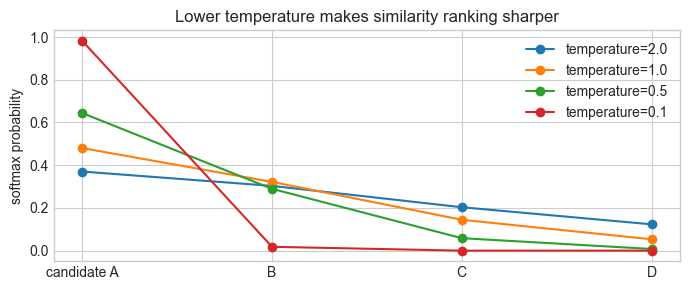

temperature=2.0: [0.3700000047683716, 0.30300000309944153, 0.2029999941587448, 0.12300000339746475]
temperature=1.0: [0.47999998927116394, 0.32199999690055847, 0.14499999582767487, 0.05299999937415123]
temperature=0.5: [0.6439999938011169, 0.289000004529953, 0.057999998331069946, 0.00800000037997961]
temperature=0.1: [0.9819999933242798, 0.017999999225139618, 0.0, 0.0]


In [3]:
# ------------------------------
# 这段代码做什么：
# 1. 用一个小分数向量演示 temperature 的作用
# 2. 说明 logit_scale 为什么会影响模型“有多自信”
# ------------------------------
raw_scores = torch.tensor([2.0, 1.6, 0.8, -0.2])
temperatures = [2.0, 1.0, 0.5, 0.1]

plt.figure(figsize=(7, 3))
for tau in temperatures:
    probs = torch.softmax(raw_scores / tau, dim=0).numpy()
    plt.plot(range(len(raw_scores)), probs, marker="o", label=f"temperature={tau}")

plt.xticks(range(len(raw_scores)), ["candidate A", "B", "C", "D"])
plt.ylabel("softmax probability")
plt.title("Lower temperature makes similarity ranking sharper")
plt.legend()
plt.tight_layout()
plt.show()

for tau in temperatures:
    probs = torch.softmax(raw_scores / tau, dim=0)
    print(f"temperature={tau}: {probs.round(decimals=3).tolist()}")

### temperature 的课堂解释

temperature 控制 softmax 的“尖锐程度”：

- **temperature 高**：概率更平，模型看起来更保守。
- **temperature 低**：概率更尖，最高分候选会拿到更多概率。
- **temperature 很低**：模型会非常自信，但这种自信不一定可靠。

关键提醒：softmax 只是把候选项重新分配概率。  
如果候选项里没有正确答案，最高概率也可能只是“相对最不坏”的答案。

课堂追问：

> 如果 temperature 很低，模型看起来会更“自信”。但这种自信一定可靠吗？

这里可以提醒大家：softmax 的最高概率只是相对候选项最高，不等于答案绝对正确。后面“候选答案都不对”的 demo 会再次看到这一点。

<img src="images/lesson6_multimodal/clip_pipeline.png" width="980">

### CLIP 的一句话直觉

- 图像编码器把图片编码成向量。
- 文本编码器把句子编码成向量。
- 同一对图文的相似度要高，错误配对的相似度要低。

这就是为什么 CLIP 训练完以后，不用再额外训练分类头，也能拿文本提示词直接做分类。

<img src="images/lesson6_multimodal/traditional_vs_clip_classifier.png" width="980">

这张图可以这样看：

- 左边传统分类器：类别输出位置是训练时固定好的，分类头像一张固定菜单。
- 右边 CLIP：类别来自临时写出的 prompt，文本编码器把 prompt 变成类别向量，再和图片向量比相似度。
- 所以 CLIP 换类别时，主要是换文本候选项，而不是重新训练一个新的分类头。

**传统分类头具体长什么样？**

传统分类器最后通常是：

```text
图像特征 h -> Linear -> logits -> Softmax -> 类别概率
```

如果有 1000 个类别，Linear 层就会输出 1000 个分数：

$$
logits = hW + b
$$

$$
p = softmax(logits)
$$

这里的 $W$ 可以理解成“1000 个类别各自的权重”。训练完成后，这 1000 个输出位置就固定了。没有 `red panda` 这个输出位置，模型就不能直接预测 `red panda`。

**论文证据：AlexNet 的 1000-way softmax**

<img src="images/lesson6_multimodal/paper_originals/alexnet_softmax_text_excerpt.png" width="900">

AlexNet 原文明确说：最后一个全连接层的输出会送入 `1000-way softmax`，产生 1000 个类别标签上的概率分布。

<img src="images/lesson6_multimodal/paper_originals/alexnet_fig2_architecture.png" width="980">

这张结构图右端的 `1000` 就是固定类别输出。它和 CLIP 的区别在于：AlexNet 的类别位置来自训练好的最后一层；CLIP 的类别可以来自推理时临时写出的文本 prompt。

## Part 3. 从零实现一个 toy CLIP

真实图文数据很复杂，容易被噪声盖住重点。所以我们先造一个小世界：

- 图像：彩色几何图形。
- 文本：`a red circle`、`a blue square`。

**猜想型问题：**

> 这个小模型最后是在学“红色”和“圆形”，还是只是在背训练集？

先让大家投票，后面用 zero-shot 和检索结果验证。

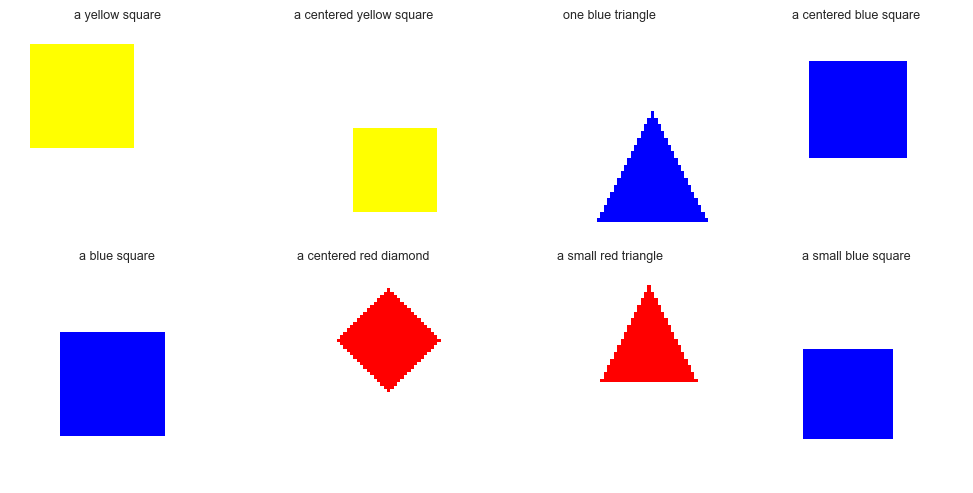

In [4]:
# ------------------------------
# 这段代码做什么：
# 1. 生成一个彩色几何图形数据集
# 2. 每张图都配一个简短文本描述，形成最小图文对
# ------------------------------
colors = ["red", "blue", "green", "yellow"]
shapes = ["circle", "square", "triangle", "diamond"]
templates = [
    "a {color} {shape}",
    "one {color} {shape}",
    "a small {color} {shape}",
    "a centered {color} {shape}",
]


def render_shape(shape, color, size=64):
    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)
    cx = random.randint(18, 46)
    cy = random.randint(18, 46)
    radius = random.randint(12, 18)

    if shape == "circle":
        draw.ellipse((cx - radius, cy - radius, cx + radius, cy + radius), fill=color)
    elif shape == "square":
        draw.rectangle((cx - radius, cy - radius, cx + radius, cy + radius), fill=color)
    elif shape == "triangle":
        draw.polygon([(cx, cy - radius), (cx - radius, cy + radius), (cx + radius, cy + radius)], fill=color)
    elif shape == "diamond":
        draw.polygon([(cx, cy - radius), (cx - radius, cy), (cx, cy + radius), (cx + radius, cy)], fill=color)

    arr = np.asarray(img).astype("float32") / 255.0
    return torch.tensor(arr).permute(2, 0, 1)


toy_samples = []
for color in colors:
    for shape in shapes:
        for _ in range(120):
            caption = random.choice(templates).format(color=color, shape=shape)
            label = f"{color} {shape}"
            toy_samples.append((render_shape(shape, color), caption, label))

random.shuffle(toy_samples)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, (image, caption, label) in zip(axes.flat, toy_samples[:8]):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(caption, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

课堂讨论：

> 如果训练数据里从来没有出现过 `a tiny green diamond`，模型有没有可能仍然选到绿色菱形？

引导大家区分两件事：

- 背模板：只记住见过的整句话。
- 学组合：知道 green 和 diamond 可以组合。

In [5]:
# ------------------------------
# 这段代码做什么：
# 1. 构造最小 tokenizer 和 Dataset
# 2. 把图像、token ids 和语义标签组织到一起
# ------------------------------
vocab = sorted(set(" ".join(caption for _, caption, _ in toy_samples).split()))
word2idx = {word: i + 1 for i, word in enumerate(vocab)}  # 0 留给 padding


def tokenize(text, max_len=6):
    ids = [word2idx[word] for word in text.split() if word in word2idx]
    ids = ids[:max_len] + [0] * max(0, max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)


class ShapeCaptionDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image, caption, label = self.samples[idx]
        return image, tokenize(caption), caption, label


full_ds = ShapeCaptionDataset(toy_samples)
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = random_split(
    full_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False)

print("vocab size =", len(vocab))
print("vocab =", vocab)
print("train size =", len(train_ds), "val size =", len(val_ds))

vocab size = 12
vocab = ['a', 'blue', 'centered', 'circle', 'diamond', 'green', 'one', 'red', 'small', 'square', 'triangle', 'yellow']
train size = 1536 val size = 384


### 代码前先看结构

这个 toy CLIP 只有三个核心部件：

1. `TinyImageEncoder`：小 CNN，把图像变成一个向量。
2. `TinyTextEncoder`：词向量求平均，把短句变成一个向量。
3. `clip_loss`：让正确图文对相似度变高，错误配对变低。

注意：这里故意不用复杂 Transformer。课堂目标是把 CLIP 的训练信号讲清楚。

In [6]:
# ------------------------------
# 这段代码做什么：
# 1. 定义一个最小 image encoder 和 text encoder
# 2. 用对比学习目标训练它们进入同一个语义空间
# ------------------------------
class TinyImageEncoder(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(96, embed_dim)

    def forward(self, images):
        feats = self.net(images).flatten(1)
        return self.proj(feats)


class TinyTextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, token_ids):
        token_embed = self.embedding(token_ids)
        mask = (token_ids != 0).unsqueeze(-1)
        pooled = (token_embed * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.proj(pooled)


class TinyCLIP(nn.Module):
    def __init__(self, vocab_size, embed_dim=64):
        super().__init__()
        self.image_encoder = TinyImageEncoder(embed_dim=embed_dim)
        self.text_encoder = TinyTextEncoder(vocab_size=vocab_size, embed_dim=embed_dim)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / 0.07)))

    def forward(self, images, token_ids):
        image_embeds = F.normalize(self.image_encoder(images), dim=1)
        text_embeds = F.normalize(self.text_encoder(token_ids), dim=1)
        scale = self.logit_scale.exp().clamp(max=100)
        logits = image_embeds @ text_embeds.T * scale
        return logits, image_embeds, text_embeds


toy_clip = TinyCLIP(vocab_size=len(vocab), embed_dim=64).to(device)
toy_opt = torch.optim.Adam(toy_clip.parameters(), lr=1e-3)


def clip_loss(logits):
    labels = torch.arange(len(logits), device=logits.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return (loss_i + loss_t) / 2


print(toy_clip)

TinyCLIP(
  (image_encoder): TinyImageEncoder(
    (net): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): AdaptiveAvgPool2d(output_size=1)
    )
    (proj): Linear(in_features=96, out_features=64, bias=True)
  )
  (text_encoder): TinyTextEncoder(
    (embedding): Embedding(13, 64, padding_idx=0)
    (proj): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
  )
)


In [7]:
# ------------------------------
# 这段代码做什么：
# 1. 训练 toy CLIP
# 2. 观察对比学习损失是否下降
# ------------------------------
toy_losses = []

for epoch in range(12):
    batch_losses = []
    toy_clip.train()
    for images, token_ids, captions, labels in train_dl:
        images = images.to(device)
        token_ids = token_ids.to(device)

        logits, _, _ = toy_clip(images, token_ids)
        loss = clip_loss(logits)

        toy_opt.zero_grad()
        loss.backward()
        toy_opt.step()
        batch_losses.append(float(loss.item()))

    epoch_loss = float(np.mean(batch_losses))
    toy_losses.append(epoch_loss)

    if epoch in [0, 3, 7, 11]:
        print(f"Epoch {epoch + 1}: loss={epoch_loss:.4f}")

Epoch 1: loss=3.5031


Epoch 4: loss=2.3875


Epoch 8: loss=1.6284


Epoch 12: loss=1.5175


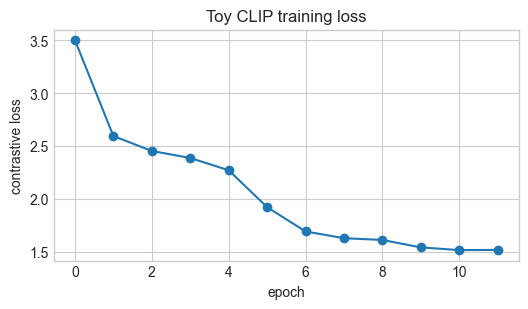

In [8]:
# ------------------------------
# 这段代码做什么：
# 1. 画出 toy CLIP 的训练 loss
# 2. 看看图文对齐是不是在逐步变好
# ------------------------------
plt.figure(figsize=(6, 3))
plt.plot(toy_losses, marker="o")
plt.title("Toy CLIP training loss")
plt.xlabel("epoch")
plt.ylabel("contrastive loss")
plt.show()

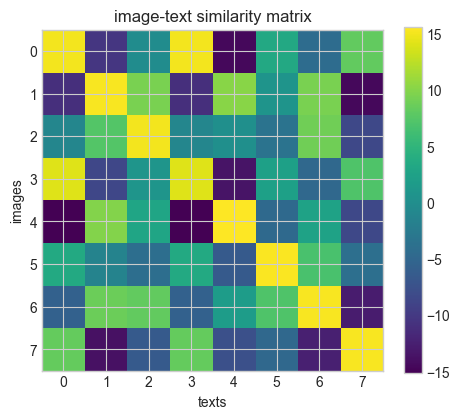

captions in this mini-batch:
0 a centered yellow diamond
1 a green square
2 a green circle
3 a centered yellow diamond
4 a centered blue square
5 a centered yellow triangle
6 one green triangle
7 a centered red diamond


In [9]:
# ------------------------------
# 这段代码做什么：
# 1. 可视化一个 mini-batch 的相似度矩阵
# 2. 看看对角线是否逐渐变亮
# ------------------------------
toy_clip.eval()
images, token_ids, captions, labels = next(iter(val_dl))
images = images[:8].to(device)
token_ids = token_ids[:8].to(device)

with torch.no_grad():
    logits, image_embeds, text_embeds = toy_clip(images, token_ids)
    sim = logits.cpu().numpy()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(sim, cmap="viridis")
ax.set_title("image-text similarity matrix")
ax.set_xlabel("texts")
ax.set_ylabel("images")
fig.colorbar(im, ax=ax)
plt.show()

print("captions in this mini-batch:")
for i, caption in enumerate(captions[:8]):
    print(i, caption)

诊断型问题：

> 如果对角线没有明显更亮，可能是哪一步出了问题？

可以让大家从这几个角度猜：

- 数据配对错了。
- encoder 太弱。
- 训练太少。
- batch 太小，负例不够。
- 文本 tokenizer 把关键信息弄丢了。

In [10]:
# ------------------------------
# 这段代码做什么：
# 1. 用一组文本提示词做 zero-shot 分类
# 2. 看 toy CLIP 是否已经学会颜色 + 形状的语义对齐
# ------------------------------
combo_prompts = [f"a {color} {shape}" for color in colors for shape in shapes]
combo_token_ids = torch.stack([tokenize(text) for text in combo_prompts]).to(device)

with torch.no_grad():
    prompt_embeds = F.normalize(toy_clip.text_encoder(combo_token_ids), dim=1)

    total = 0
    correct = 0
    for images, token_ids, captions, labels in val_dl:
        images = images.to(device)
        image_embeds = F.normalize(toy_clip.image_encoder(images), dim=1)
        pred = (image_embeds @ prompt_embeds.T).argmax(dim=1)
        pred_labels = [combo_prompts[i].replace("a ", "") for i in pred.tolist()]
        correct += sum(int(p == y) for p, y in zip(pred_labels, labels))
        total += len(labels)

print("toy zero-shot accuracy =", round(correct / total, 3))

toy zero-shot accuracy = 1.0


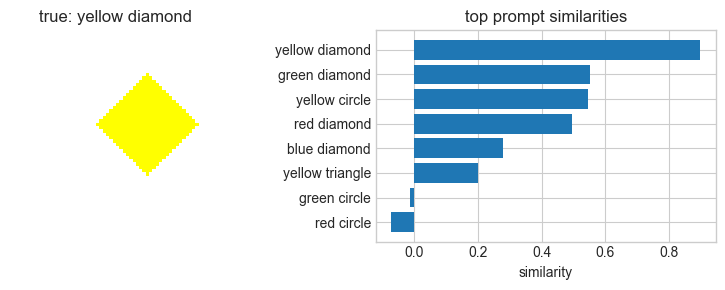

original caption: a centered yellow diamond


In [11]:
# ------------------------------
# 这段代码做什么：
# 1. 选一张 toy 图片
# 2. 画出它和所有 prompt 的相似度排名
# ------------------------------
demo_image, _, demo_caption, demo_label = val_ds[0]
demo_image_batch = demo_image.unsqueeze(0).to(device)

with torch.no_grad():
    image_embed = F.normalize(toy_clip.image_encoder(demo_image_batch), dim=1)
    scores = (image_embed @ prompt_embeds.T).squeeze(0).cpu()

order = scores.argsort(descending=True)
top_prompts = [combo_prompts[i].replace("a ", "") for i in order[:8].tolist()]
top_scores = scores[order[:8]].numpy()

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(demo_image.permute(1, 2, 0))
plt.title(f"true: {demo_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.barh(top_prompts[::-1], top_scores[::-1])
plt.title("top prompt similarities")
plt.xlabel("similarity")
plt.tight_layout()
plt.show()

print("original caption:", demo_caption)

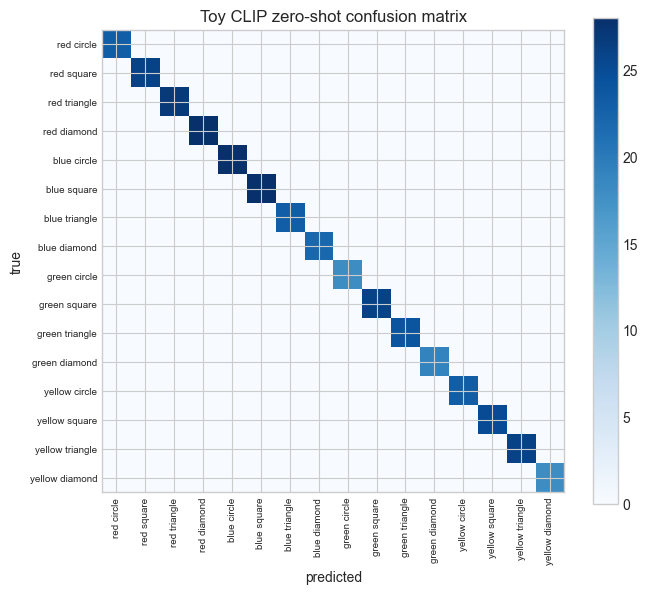

In [12]:
# ------------------------------
# 这段代码做什么：
# 1. 统计 toy CLIP 在 16 个颜色+形状类别上的混淆情况
# 2. 看模型主要错在颜色、形状，还是两者都错
# ------------------------------
label_names = [f"{color} {shape}" for color in colors for shape in shapes]
label_to_id = {name: i for i, name in enumerate(label_names)}
confusion = np.zeros((len(label_names), len(label_names)), dtype=int)

with torch.no_grad():
    for images, token_ids, captions, labels in val_dl:
        images = images.to(device)
        image_embeds = F.normalize(toy_clip.image_encoder(images), dim=1)
        pred = (image_embeds @ prompt_embeds.T).argmax(dim=1)
        pred_labels = [combo_prompts[i].replace("a ", "") for i in pred.tolist()]
        for y_true, y_pred in zip(labels, pred_labels):
            confusion[label_to_id[y_true], label_to_id[y_pred]] += 1

plt.figure(figsize=(7, 6))
plt.imshow(confusion, cmap="Blues")
plt.xticks(range(len(label_names)), label_names, rotation=90, fontsize=7)
plt.yticks(range(len(label_names)), label_names, fontsize=7)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("Toy CLIP zero-shot confusion matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

讨论题：看混淆矩阵时，不要只问“准确率多少”，要问：

- 错误是不是集中在同一颜色？
- 错误是不是集中在同一形状？
- 如果把训练数据里的模板减少一半，模型会更像“背答案”还是更像“学组合”？



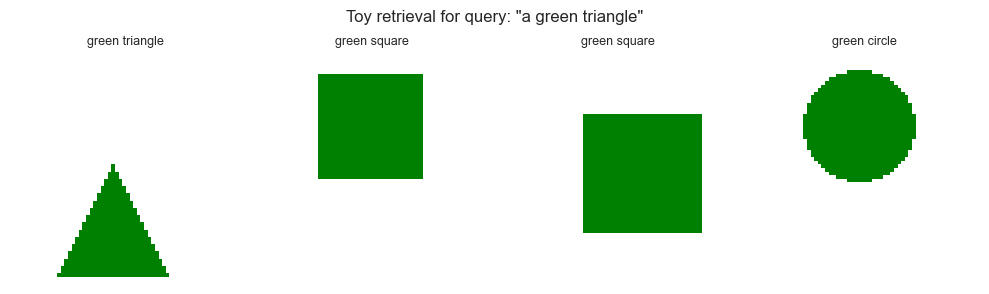

In [13]:
# ------------------------------
# 这段代码做什么：
# 1. 给一个文本查询，从 toy gallery 里检索最相近图像
# 2. 对应 text-to-image retrieval
# ------------------------------
query_text = "a green triangle"
gallery_images, _, gallery_captions, gallery_labels = next(iter(val_dl))
gallery_images = gallery_images[:24].to(device)

with torch.no_grad():
    gallery_embeds = F.normalize(toy_clip.image_encoder(gallery_images), dim=1)
    query_embed = F.normalize(toy_clip.text_encoder(tokenize(query_text).unsqueeze(0).to(device)), dim=1)
    scores = (gallery_embeds @ query_embed.T).squeeze(1)
    topk = scores.topk(4).indices.cpu().tolist()

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, idx in zip(axes, topk):
    ax.imshow(gallery_images[idx].cpu().permute(1, 2, 0))
    ax.set_title(gallery_labels[idx], fontsize=9)
    ax.axis("off")
plt.suptitle(f'Toy retrieval for query: "{query_text}"')
plt.tight_layout()
plt.show()

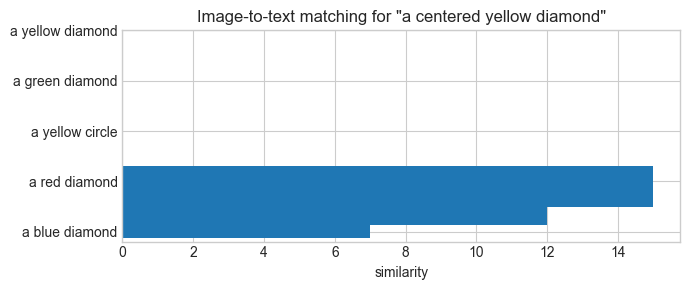

true caption: a centered yellow diamond
0.898  a yellow diamond
0.551  a green diamond
0.545  a yellow circle
0.495  a red diamond
0.277  a blue diamond


In [14]:
# ------------------------------
# 这段代码做什么：
# 1. 给一张 toy 图片，从多个文本 prompt 中找最匹配的一句
# 2. 说明 image-to-text matching 和分类是同一类动作
# ------------------------------
combo_prompts = [f"a {color} {shape}" for color in colors for shape in shapes]
combo_token_ids = torch.stack([tokenize(text) for text in combo_prompts]).to(device)

with torch.no_grad():
    prompt_embeds = F.normalize(toy_clip.text_encoder(combo_token_ids), dim=1)

image_idx = 0
query_image, _, query_caption, query_label = val_ds[image_idx]
query_image_batch = query_image.unsqueeze(0).to(device)

with torch.no_grad():
    image_embed = F.normalize(toy_clip.image_encoder(query_image_batch), dim=1)
    scores = (image_embed @ prompt_embeds.T).squeeze(0).cpu()

topk = scores.topk(5)

plt.figure(figsize=(7, 3))
plt.barh(topk.values.numpy()[::-1], topk.indices.numpy()[::-1])
plt.yticks(range(len(topk.indices)), [combo_prompts[i] for i in topk.indices.numpy()[::-1]])
plt.xlabel("similarity")
plt.title(f'Image-to-text matching for "{query_caption}"')
plt.tight_layout()
plt.show()

print("true caption:", query_caption)
for score, idx in zip(topk.values, topk.indices):
    print(f"{score.item():.3f}  {combo_prompts[idx]}")

### 小结：分类、检索、VQA 为什么能统一？

这三个任务表面不同，但 CLIP 的处理方式很像：

| 任务 | 输入 | 候选项 | CLIP 做什么 |
|---|---|---|---|
| 分类 | 图片 | 类别 prompt | 给类别排序 |
| 检索 | 文本或图片 | 图片库或文本库 | 给候选样本排序 |
| 多选式 VQA | 图片 + 选项 | 候选答案 | 给答案选项排序 |

所以 CLIP 的核心能力可以概括成一句话：

> **把跨模态问题改写成“谁和谁更像”的排序问题。**

---

### 补充解释：多选式 VQA 是什么意思？

**VQA** 是 **Visual Question Answering**，也就是“视觉问答”。

普通 VQA 通常是：

```text
输入：一张图片 + 一个问题
输出：一个自然语言答案
```

例如：

```text
图片：一只猫
问题：What animal is in the image?
答案：cat
```

**多选式 VQA** 则不是让模型自由生成答案，而是给模型几个选项，让模型从中选一个。

例如：

```text
图片：一只猫
问题：What animal is in the image?

选项：
A. cat
B. dog
C. bird
D. horse
```

模型只需要选：

```text
A. cat
```

所以多选式 VQA 可以理解为：

> **看图后，在候选答案中选最匹配的一个。**

---

### 多选式 VQA 和 CLIP 有什么关系？

CLIP 本身不是传统意义上的自由生成式 VQA 模型。

它不会像 GPT-4V / LLaVA 那样看图聊天、自由生成一段回答。

但是 CLIP 可以做“多选式 VQA 风格”的任务。

做法是：

```text
图片向量 vs 候选答案文本向量
```

然后选相似度最高的答案。

例如图片是一只猫，候选答案是：

```text
the answer is cat
the answer is dog
the answer is bird
the answer is horse
```

CLIP 会计算：

```text
图片 vs "the answer is cat"
图片 vs "the answer is dog"
图片 vs "the answer is bird"
图片 vs "the answer is horse"
```

最后选分数最高的：

```text
the answer is cat
```

这就是 notebook 里“多选式 VQA 风格示例”的意思。

---

### 多选式 VQA 和普通分类有什么关系？

多选式 VQA 和普通分类非常像。

| 任务 | 输入 | 候选项 | 输出 |
|---|---|---|---|
| 普通分类 | 图片 | 类别名 | 选一个类别 |
| 多选式 VQA | 图片 + 问题 | 候选答案 | 选一个答案 |

所以多选式 VQA 可以看成：

> **带问题上下文的分类 / 答案排序。**

---

### 多选式 VQA 和自由生成式 VQA 的区别

| 类型 | 模型做什么 | 例子 |
|---|---|---|
| 多选式 VQA | 从选项里选一个 | A. cat, B. dog, C. bird |
| 自由生成式 VQA | 自己生成自然语言答案 | “There is a cat sitting on a sofa.” |

CLIP 更适合多选式 VQA，不太适合自由生成式 VQA。

因为 CLIP 的核心是：

```text
图片和文本谁更像？
```

而不是：

```text
根据图片生成一段回答。
```

---

### 课堂一句话解释

多选式 VQA 是：

> **给模型一张图、一个问题和几个答案选项，让模型选最像图片的那个答案。**

一句话总结：

> **多选式 VQA 是“看图选答案”，不是“看图写作文”。**


In [15]:
# ------------------------------
# 这段代码做什么：
# 1. 测试 toy tokenizer 遇到没见过的词会怎样
# 2. 说明 toy 模型的泛化边界
# ------------------------------
test_queries = [
    "a green triangle",
    "a tiny green triangle",
    "a bright green triangle",
    "a green object",
]

gallery_images, _, gallery_captions, gallery_labels = next(iter(val_dl))
gallery_images = gallery_images[:32].to(device)

with torch.no_grad():
    gallery_embeds = F.normalize(toy_clip.image_encoder(gallery_images), dim=1)

for query_text in test_queries:
    query_ids = tokenize(query_text).unsqueeze(0).to(device)
    with torch.no_grad():
        query_embed = F.normalize(toy_clip.text_encoder(query_ids), dim=1)
        scores = (gallery_embeds @ query_embed.T).squeeze(1)
    top = scores.argmax().item()
    print(f"{query_text:>24s} -> top match: {gallery_labels[top]}")

print("\n注意：tiny、bright、object 如果不在词表里，会被这个最小 tokenizer 忽略。")

        a green triangle -> top match: green triangle
   a tiny green triangle -> top match: green triangle
 a bright green triangle -> top match: green triangle
          a green object -> top match: green circle

注意：tiny、bright、object 如果不在词表里，会被这个最小 tokenizer 忽略。


小结讨论：

> zero-shot 分类到底神奇在哪里？又不神奇在哪里？

可以引导大家回答：

- 神奇：没有给新分类头训练参数，直接用文本当类别。
- 不神奇：它本质上还是相似度比较，不是凭空冒出来的能力。

## Part 4. 预训练 OpenAI CLIP：真实 demo

现在把视角从 toy 数据换到真实模型。


<img src="images/lesson6_multimodal/zero_shot_pipeline.png" width="980">

### 真实 CLIP 的直觉

现在从 toy 数据换到真实模型。  
这里的核心不是代码细节，而是验证一个问题：

> `cat` 和 `a photo of a cat` 对人来说差不多，为什么对模型可能不一样？

因为 CLIP 看到的是文本编码器得到的向量，而不是人类理解后的语义。prompt 的措辞会改变文本向量，所以也会改变相似度排序。

### 论文原图：prompt engineering 的影响

**CLIP Figure 4：prompt engineering and ensembling**

<img src="images/lesson6_multimodal/paper_originals/clip_fig4_prompt_engineering.png" width="700">

这张原图非常适合放在 prompt demo 前面。

课堂问题：

> prompt 明明只是换了说法，为什么模型结果会变？

接下来用 CIFAR10 的 prompt 对照实验来验证这个问题。

In [16]:
# ------------------------------
# 这段代码做什么：
# 1. 载入预训练 OpenAI CLIP
# 2. 准备 CIFAR10 作为真实图像演示数据
# ------------------------------
cifar_val = datasets.CIFAR10(root="cifar_data", train=False, download=True)
cifar_classes = cifar_val.classes

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", use_fast=False)
clip_model.eval()

print("num classes =", len(cifar_classes))
print("classes =", cifar_classes)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


num classes = 10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


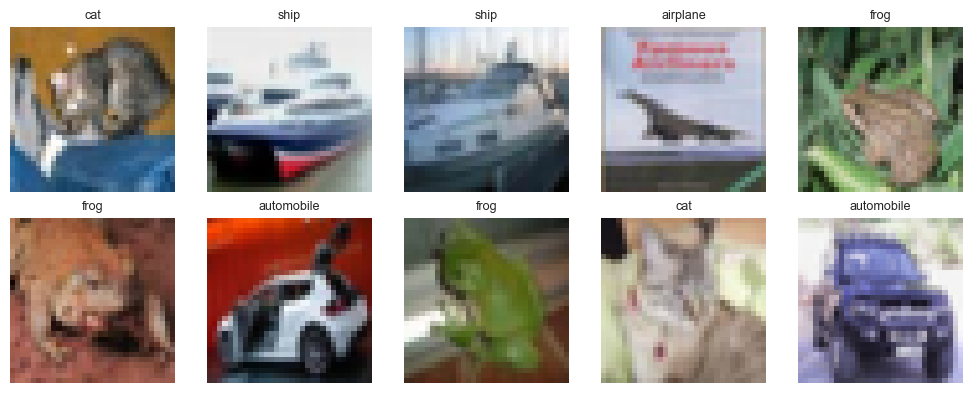

In [17]:
# ------------------------------
# 这段代码做什么：
# 1. 先看几张 CIFAR10 样本图
# 2. 为后面的 zero-shot 和检索做参照
# ------------------------------
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    image, label = cifar_val[idx]
    ax.imshow(image)
    ax.set_title(cifar_classes[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

    label_only: acc=0.875


  photo_prompt: acc=0.917


  blurry_photo: acc=0.892


  small_object: acc=0.892


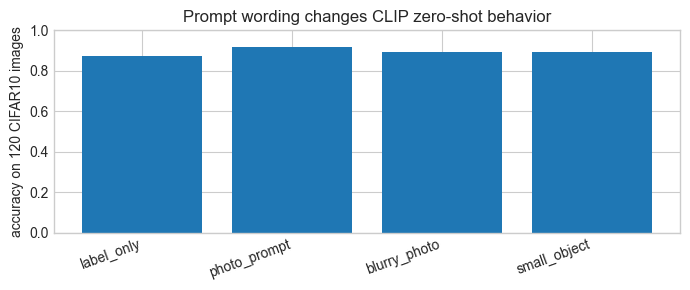

In [18]:
# ------------------------------
# 这段代码做什么：
# 1. 设计一个 prompt 挑战
# 2. 比较不同文本模板的 zero-shot 准确率
# ------------------------------
eval_images = [cifar_val[i][0] for i in range(120)]
eval_true = [cifar_classes[cifar_val[i][1]] for i in range(120)]

prompt_sets = {
    "label_only": list(cifar_classes),
    "photo_prompt": [f"a photo of a {name}" for name in cifar_classes],
    "blurry_photo": [f"a blurry photo of a {name}" for name in cifar_classes],
    "small_object": [f"a small object that is a {name}" for name in cifar_classes],
}

prompt_scores = {}
for prompt_name, texts in prompt_sets.items():
    inputs = clip_processor(text=texts, images=eval_images, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = clip_model(**inputs).logits_per_image.softmax(dim=1)

    preds = [cifar_classes[i] for i in probs.argmax(dim=1).tolist()]
    acc = sum(int(p == y) for p, y in zip(preds, eval_true)) / len(eval_true)
    prompt_scores[prompt_name] = acc
    print(f"{prompt_name:>14s}: acc={acc:.3f}")

plt.figure(figsize=(7, 3))
plt.bar(prompt_scores.keys(), prompt_scores.values())
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.ylabel("accuracy on 120 CIFAR10 images")
plt.title("Prompt wording changes CLIP zero-shot behavior")
plt.tight_layout()
plt.show()

In [19]:
# ------------------------------
# 这段代码做什么：
# 1. 用多个 prompt 模板做 prompt ensemble
# 2. 对比单模板和多模板平均的效果
# ------------------------------
ensemble_templates = [
    "a photo of a {}",
    "a blurry photo of a {}",
    "a small photo of a {}",
    "a close-up photo of a {}",
    "a low resolution photo of a {}",
]

all_texts = [template.format(name) for template in ensemble_templates for name in cifar_classes]
text_inputs = clip_processor(text=all_texts, return_tensors="pt", padding=True)
text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

image_inputs = clip_processor(images=eval_images, return_tensors="pt")
image_inputs = {k: v.to(device) for k, v in image_inputs.items()}

def as_feature_tensor(features):
    """兼容不同 transformers 版本：有的返回 tensor，有的返回带 pooler_output 的对象。"""
    if isinstance(features, torch.Tensor):
        return features
    if hasattr(features, "pooler_output"):
        return features.pooler_output
    if isinstance(features, (tuple, list)):
        return features[0]
    raise TypeError(f"Unsupported feature output type: {type(features)}")

with torch.no_grad():
    text_features = as_feature_tensor(clip_model.get_text_features(**text_inputs))
    image_features = as_feature_tensor(clip_model.get_image_features(**image_inputs))

text_features = F.normalize(text_features, dim=1)
image_features = F.normalize(image_features, dim=1)

n_templates = len(ensemble_templates)
n_classes = len(cifar_classes)
text_features = text_features.reshape(n_templates, n_classes, -1)

single_text_features = text_features[0]
ensemble_text_features = F.normalize(text_features.mean(dim=0), dim=1)

single_pred = (image_features @ single_text_features.T).argmax(dim=1).cpu().tolist()
ensemble_pred = (image_features @ ensemble_text_features.T).argmax(dim=1).cpu().tolist()

single_acc = sum(cifar_classes[i] == y for i, y in zip(single_pred, eval_true)) / len(eval_true)
ensemble_acc = sum(cifar_classes[i] == y for i, y in zip(ensemble_pred, eval_true)) / len(eval_true)

print("single prompt acc   =", round(single_acc, 3))
print("prompt ensemble acc =", round(ensemble_acc, 3))

single prompt acc   = 0.917
prompt ensemble acc = 0.925


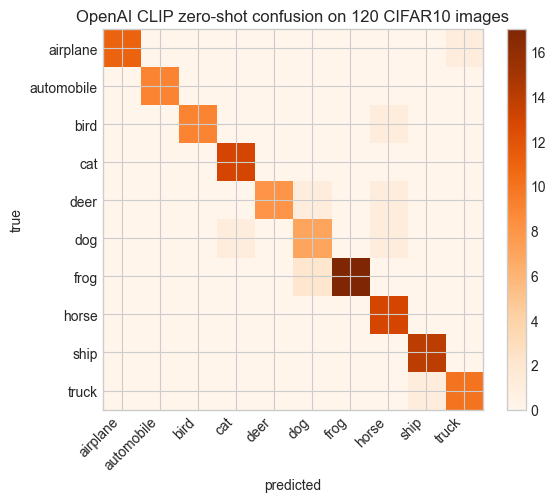

In [20]:
# ------------------------------
# 这段代码做什么：
# 1. 画出预训练 CLIP 在 CIFAR10 小样本上的混淆矩阵
# 2. 观察它更容易混淆哪些类别
# ------------------------------
confusion = np.zeros((len(cifar_classes), len(cifar_classes)), dtype=int)
for pred_id, true_name in zip(ensemble_pred, eval_true):
    true_id = cifar_classes.index(true_name)
    confusion[true_id, pred_id] += 1

plt.figure(figsize=(6, 5))
plt.imshow(confusion, cmap="Oranges")
plt.xticks(range(len(cifar_classes)), cifar_classes, rotation=45, ha="right")
plt.yticks(range(len(cifar_classes)), cifar_classes)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("OpenAI CLIP zero-shot confusion on 120 CIFAR10 images")
plt.colorbar()
plt.tight_layout()
plt.show()

诊断型问题：

> prompt 是给人看的，还是给模型看的？

建议让大家课后先自己写 2 到 3 个 prompt，再替换上面 `prompt_sets` 里的模板。

讨论重点：prompt 不是装饰，它会改变文本向量，所以会改变相似度排序。


true = cat
         cat: 0.415
         dog: 0.211
        ship: 0.104

true = ship
        ship: 0.989
  automobile: 0.007
    airplane: 0.002

true = airplane
    airplane: 0.568
        bird: 0.336
  automobile: 0.049

true = cat
         cat: 0.953
         dog: 0.032
       horse: 0.004

true = dog
         dog: 0.772
         cat: 0.189
       horse: 0.015


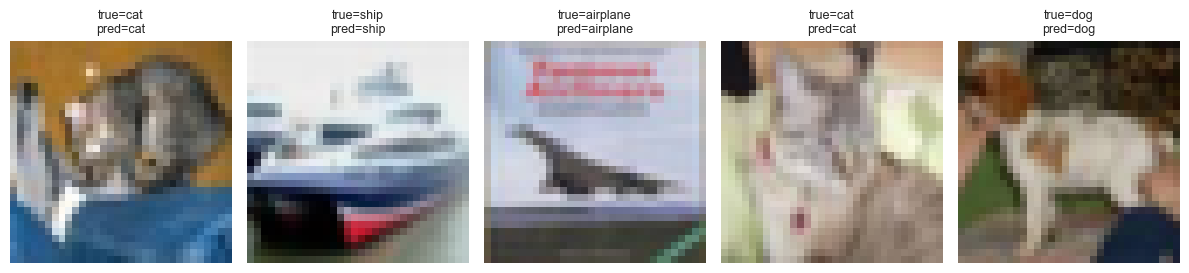

In [21]:
# ------------------------------
# 这段代码做什么：
# 1. 对几张真实图像做 zero-shot 分类
# 2. 打印 top-3 文本提示词概率
# ------------------------------
sample_indices = [0, 1, 3, 8, 12]
sample_images = [cifar_val[i][0] for i in sample_indices]
sample_true = [cifar_classes[cifar_val[i][1]] for i in sample_indices]
candidate_texts = [f"a photo of a {name}" for name in cifar_classes]

inputs = clip_processor(text=candidate_texts, images=sample_images, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    probs = clip_model(**inputs).logits_per_image.softmax(dim=1).cpu()

fig, axes = plt.subplots(1, len(sample_images), figsize=(12, 3))
for ax, image, true_label, prob in zip(axes, sample_images, sample_true, probs):
    top_vals, top_idx = prob.topk(3)
    pred_name = cifar_classes[int(top_idx[0])]
    ax.imshow(image)
    ax.set_title(f"true={true_label}\npred={pred_name}", fontsize=9)
    ax.axis("off")

    print("\ntrue =", true_label)
    for value, idx in zip(top_vals.tolist(), top_idx.tolist()):
        print(f"  {cifar_classes[idx]:>10s}: {value:.3f}")

plt.tight_layout()
plt.show()

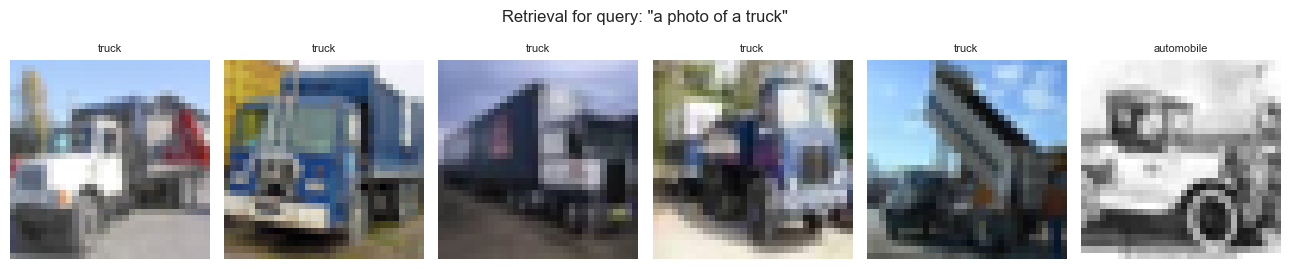

In [22]:
# ------------------------------
# 这段代码做什么：
# 1. 用文本查询在小型图像库里做检索
# 2. 观察 CLIP 的 text-to-image retrieval 能力
# ------------------------------
gallery_indices = list(range(60))
gallery_images = [cifar_val[i][0] for i in gallery_indices]
gallery_labels = [cifar_classes[cifar_val[i][1]] for i in gallery_indices]
query = "a photo of a truck"

inputs = clip_processor(text=[query], images=gallery_images, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    scores = clip_model(**inputs).logits_per_text[0].cpu()

top_idx = scores.topk(6).indices.tolist()

fig, axes = plt.subplots(1, 6, figsize=(13, 2.8))
for ax, idx in zip(axes, top_idx):
    ax.imshow(gallery_images[idx])
    ax.set_title(gallery_labels[idx], fontsize=8)
    ax.axis("off")
plt.suptitle(f'Retrieval for query: "{query}"')
plt.tight_layout()
plt.show()

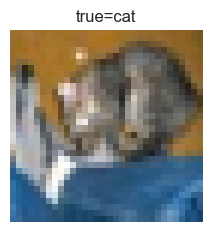

0.701  a photo of a cat
0.175  a photo of a ship
0.062  a photo of a horse
0.029  a photo of an airplane
0.019  a close-up photo of a frog
0.014  a photo of a truck


In [23]:
# ------------------------------
# 这段代码做什么：
# 1. 反过来：给一张图片，从多个文本描述中找最匹配的一句
# 2. 说明 image-to-text matching 和分类是同一类动作
# ------------------------------
image_idx = 0
query_image, true_id = cifar_val[image_idx]
text_bank = [
    "a photo of an airplane",
    "a photo of a ship",
    "a photo of a truck",
    "a close-up photo of a frog",
    "a photo of a cat",
    "a photo of a horse",
]

inputs = clip_processor(text=text_bank, images=[query_image], return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    probs = clip_model(**inputs).logits_per_image.softmax(dim=1)[0].cpu()

plt.figure(figsize=(2.5, 2.5))
plt.imshow(query_image)
plt.axis("off")
plt.title(f"true={cifar_classes[true_id]}")
plt.show()

for text, prob in sorted(zip(text_bank, probs.tolist()), key=lambda x: x[1], reverse=True):
    print(f"{prob:.3f}  {text}")

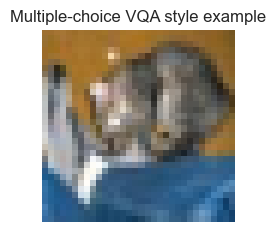

     the answer is cat: 0.553
     the answer is dog: 0.179
    the answer is bird: 0.207
   the answer is horse: 0.061


In [24]:
# ------------------------------
# 这段代码做什么：
# 1. 用 CLIP 做一个“多选式 VQA”示意
# 2. 说明它本质上是答案排序，而不是自由生成
# ------------------------------
cat_idx = next(i for i, (_, y) in enumerate(cifar_val) if cifar_classes[y] == "cat")
qa_image, _ = cifar_val[cat_idx]
answer_choices = [
    "the answer is cat",
    "the answer is dog",
    "the answer is bird",
    "the answer is horse",
]

inputs = clip_processor(text=answer_choices, images=[qa_image], return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    answer_probs = clip_model(**inputs).logits_per_image.softmax(dim=1)[0].cpu()

plt.figure(figsize=(2.5, 2.5))
plt.imshow(qa_image)
plt.axis("off")
plt.title("Multiple-choice VQA style example")
plt.show()

for choice, prob in zip(answer_choices, answer_probs.tolist()):
    print(f"{choice:>22s}: {prob:.3f}")

课堂追问：

> CLIP 选出了 `the answer is cat`，这算不算真正理解了问题？

这里要明确区分：

- CLIP 可以做一些“像问答”的事情。
- 但它的机制仍然是“图片向量 vs 候选答案向量”的排序。
- 所以它更像 answer selection，不是现代视觉语言模型那种自由生成式 VQA。

### 从 CLIP 到现代 VLM：再看三张论文图

到这里的三张原论文图，帮助大家理解：CLIP 是很重要的地基，但现代视觉语言模型还多了“桥”和“语言生成”。

1. **BLIP-2 架构图**：看 Q-Former 怎么站在冻结图像编码器和冻结大语言模型中间。  
   课堂问题：为什么不直接把图片向量塞进大语言模型？

2. **Flamingo 架构图**：看视觉特征如何通过 cross-attention 进入语言模型。  
   课堂问题：如果输入里有多张图和多段文字，模型应该怎么知道每句话对应哪张图？

3. **LLaVA 流程图**：看 CLIP 视觉编码器、投影层、语言模型和指令数据如何连起来。  
   课堂问题：为什么“会匹配图文”还不等于“会聊天回答问题”？

一句话总结：

> CLIP 解决“图文能不能对齐”；VLM 还要解决“视觉信息怎么进入语言模型，并按人类指令回答”。

### 论文原图：BLIP-2、Flamingo、LLaVA

**BLIP-2 Figure 1：整体框架**

<img src="images/lesson6_multimodal/paper_originals/blip2_fig1_framework.png" width="760">

**BLIP-2 Figure 2：Q-Former**

<img src="images/lesson6_multimodal/paper_originals/blip2_fig2_qformer.png" width="980">

这两张图要讲清楚：BLIP-2 不是简单把图片丢给 LLM，而是用 Q-Former 做中间桥。

**Flamingo Figure 3：VLM 架构**

<img src="images/lesson6_multimodal/paper_originals/flamingo_fig3_architecture.png" width="980">

这张图重点看：视觉编码器和语言模型很多部分是冻结的，中间通过 cross-attention 类模块连接。

**Flamingo Figure 1：少样本视觉语言任务效果**

<img src="images/lesson6_multimodal/paper_originals/flamingo_fig1_examples.png" width="760">

这张效果图适合让大家观察：同一个模型如何处理分类、问答、描述等不同任务。

**LLaVA Figure 1：视觉指令微调架构**

<img src="images/lesson6_multimodal/paper_originals/llava_fig1_architecture.png" width="800">

这张图重点看：CLIP 视觉编码器输出图像特征，再通过投影层接入语言模型。

**LLaVA Figure 2：根据草图生成网页**

<img src="images/lesson6_multimodal/paper_originals/llava_fig2_demo.png" width="780">

这张效果图适合讨论：

> 为什么从“图文匹配”走到“按指令生成答案/代码”，中间还需要指令数据和语言模型？

## Part 5. CLIP 的局限：它会怎么翻车？

<img src="images/lesson6_multimodal/clip_failure_cases.png" width="980">

辩论型问题：

> CLIP 是在理解图像，还是在做高级匹配？

这不是非黑即白的问题。更好的说法是：

> CLIP 学到了很强的图文匹配能力，但“匹配很强”不等于“所有视觉推理都很强”。

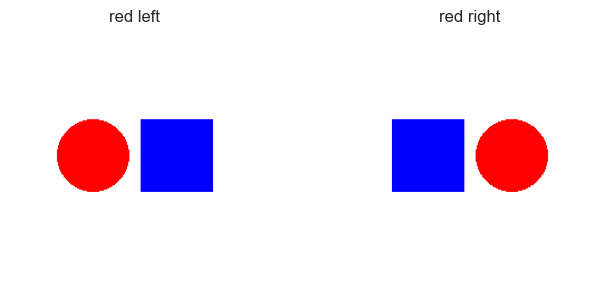


 red left image
0.325  a blue square to the right of a red circle
0.257  a red circle to the left of a blue square
0.218  a blue square to the left of a red circle
0.201  a red circle to the right of a blue square

 red right image
0.328  a blue square to the right of a red circle
0.251  a red circle to the left of a blue square
0.216  a blue square to the left of a red circle
0.206  a red circle to the right of a blue square


In [25]:
# ------------------------------
# 这段代码做什么：
# 1. 构造两个只有左右关系不同的合成图片
# 2. 测试 CLIP 对 left/right 关系是否稳定
# ------------------------------
def render_two_shape_scene(red_left=True, size=224):
    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)
    y = size // 2
    left_x, right_x = size // 3, 2 * size // 3
    red_x = left_x if red_left else right_x
    blue_x = right_x if red_left else left_x

    draw.ellipse((red_x - 32, y - 32, red_x + 32, y + 32), fill="red")
    draw.rectangle((blue_x - 32, y - 32, blue_x + 32, y + 32), fill="blue")
    return img


spatial_images = [
    render_two_shape_scene(red_left=True),
    render_two_shape_scene(red_left=False),
]
spatial_texts = [
    "a red circle to the left of a blue square",
    "a red circle to the right of a blue square",
    "a blue square to the left of a red circle",
    "a blue square to the right of a red circle",
]

inputs = clip_processor(text=spatial_texts, images=spatial_images, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    probs = clip_model(**inputs).logits_per_image.softmax(dim=1).cpu()

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, image, title in zip(axes, spatial_images, ["red left", "red right"]):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

for image_name, prob in zip(["red left image", "red right image"], probs):
    print("\n", image_name)
    for text, value in sorted(zip(spatial_texts, prob.tolist()), key=lambda x: x[1], reverse=True):
        print(f"{value:.3f}  {text}")

讨论题：

> 如果模型看到了 red、circle、blue、square，但 left/right 判断不稳定，这说明它缺的是视觉能力，还是语言关系理解能力？

引导大家注意：很多图文模型对“物体是什么”很强，但对“谁在谁左边、数量是多少、细小文字写了什么”不一定稳定。

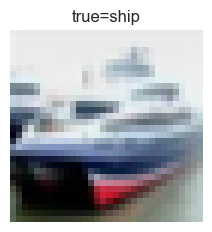

0.974  the image shows a vehicle or vessel
0.016  the image shows two red cars
0.010  the image shows a large animal
0.000  the image shows an indoor bedroom


In [26]:
# ------------------------------
# 这段代码做什么：
# 1. 构造一个“候选答案都不完美”的多选题
# 2. 观察 CLIP 仍然会给出一个最高分
# ------------------------------
image_idx = next(i for i, (_, y) in enumerate(cifar_val) if cifar_classes[y] == "ship")
tricky_image, true_id = cifar_val[image_idx]
tricky_choices = [
    "the image shows two red cars",
    "the image shows a large animal",
    "the image shows an indoor bedroom",
    "the image shows a vehicle or vessel",
]

inputs = clip_processor(text=tricky_choices, images=[tricky_image], return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    probs = clip_model(**inputs).logits_per_image.softmax(dim=1)[0].cpu()

plt.figure(figsize=(2.5, 2.5))
plt.imshow(tricky_image)
plt.axis("off")
plt.title(f"true={cifar_classes[true_id]}")
plt.show()

for choice, prob in sorted(zip(tricky_choices, probs.tolist()), key=lambda x: x[1], reverse=True):
    print(f"{prob:.3f}  {choice}")

讨论提示：

> 如果所有候选答案都不准确，CLIP 会不会说“我不知道”？

通常不会。因为这里用的是 softmax 排序，它总会把概率分出去。  
这就是为什么实际系统里还需要阈值、拒答机制、人工检查或更强的视觉语言模型。

## Part 6. CLIP 编码器和 T5 编码器各负责什么

<img src="images/lesson6_multimodal/encoder_roles.png" width="980">

一句话版：

> **CLIP 像一个会判断“图文像不像一对”的裁判；T5 编码器像一个读题很细的语文老师。**

它们都叫 encoder，都是把输入变成向量，但后面的模型拿这些向量做的事不一样。

- **CLIP image encoder**：把图片变成图像向量。
- **CLIP text encoder**：把短文本、类别名、prompt 模板变成文本向量。
- **CLIP 的强项**：图像向量和文本向量可以直接比相似度。
- **T5 encoder**：把较长提示词变成一串 token 级别的语言表示。
- **T5 的强项**：保留“谁修饰谁、位置关系、文字内容、长描述”等细节。

### CLIPText 和 T5：都叫 encoder，但分工不同

它们都把文字变成表示，但适合的场景不一样。

| 编码器 | 更像什么 | 适合处理 | 容易忽略 |
|---|---|---|---|
| CLIPText | 图文匹配裁判 | 短 prompt、类别名、总体语义 | 长句细节、复杂关系 |
| T5 encoder | 读题老师 | 长 prompt、修饰语、关系、属性绑定 | 需要生成模型真正利用这些细节 |

一句话：

> **CLIP 帮你判断“像不像”；T5 帮你读清楚“到底要求什么”。**

### 短 prompt vs 长 prompt：信息量差在哪里？

短 prompt：

```text
a red car
```

长 prompt：

```text
a shiny red sports car parked on a rainy street at night, with reflections on the wet road and city lights in the background
```

长 prompt 多出来的不只是词，而是几类更难的信息：

- 材质：`shiny`
- 车型：`sports car`
- 场景：`rainy street at night`
- 光照：`city lights`
- 细节：`reflections on the wet road`

CLIP 可能能抓住“red car”的总体语义；T5 更擅长把后面这些细节读成更细的语言条件。

### 哪些 prompt 最容易先出问题？

文生图模型最容易在这些 prompt 上翻车：

| 类型 | 例子 | 为什么难 |
|---|---|---|
| 数量 | `three red cars` | 容易少画、多画、颜色串 |
| 位置 | `a red car to the left of a blue bus` | 左右关系容易错 |
| 属性绑定 | `a red circle and a blue square` | 可能变成红蓝混合 |
| 文字内容 | `a sign that says OPEN` | 小文字生成不稳定 |
| 长距离依赖 | `the woman wearing the red hat is holding a blue umbrella` | 谁戴帽子、谁拿伞容易混淆 |
| 多主体互动 | `a dog chasing a cat around a table` | 主体关系和动作容易乱 |

这些问题通常不是“有没有看懂一个词”，而是“有没有把多个条件同时约束住”。

In [27]:
# ------------------------------
# 这段代码做什么：
# 1. 用简单规则估算 prompt 复杂度
# 2. 比较短 prompt、长 prompt、关系 prompt 的差异
# ------------------------------
prompts = [
    "a red car",
    "a shiny red sports car",
    "a shiny red sports car parked on a rainy street at night",
    "three red cars parked to the left of a blue bus",
    "a woman wearing a red hat is holding a blue umbrella next to a sign that says OPEN",
]

def count_words(text):
    return len(text.split())

def count_attributes(text):
    markers = ["red", "blue", "green", "shiny", "small", "large", "night", "rainy"]
    return sum(marker in text for marker in markers)

def has_relation(text):
    markers = ["left of", "right of", "next to", "holding", "wearing", "says"]
    return any(marker in text for marker in markers)

print("prompt | words | attributes | relation")
print("--- | ---: | ---: | ---")
for p in prompts:
    print(f"`{p}` | {count_words(p)} | {count_attributes(p)} | {has_relation(p)}")

prompt | words | attributes | relation
--- | ---: | ---: | ---
`a red car` | 3 | 1 | False
`a shiny red sports car` | 5 | 2 | False
`a shiny red sports car parked on a rainy street at night` | 12 | 4 | False
`three red cars parked to the left of a blue bus` | 11 | 2 | True
`a woman wearing a red hat is holding a blue umbrella next to a sign that says OPEN` | 18 | 2 | True


### T5 / Imagen / SD3 论文证据卡

<img src="images/lesson6_multimodal/imagen_text_encoder_card.png" width="980">

论文依据：

1. [T5: Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683)  
   T5 把很多语言任务统一成“输入文本，输出文本”的形式，形成了很强的语言编码能力。
2. [Imagen: Photorealistic Text-to-Image Diffusion Models with Deep Language Understanding](https://arxiv.org/abs/2205.11487)  
   Imagen 使用冻结的 T5 文本编码器作为图像生成条件，并强调强文本编码器对复杂提示词很重要。
3. [Stable Diffusion 3: Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206)  
   SD3 同时使用 CLIP 系列文本表示和 T5 文本表示，说明二者更像互补，而不是谁替代谁。


### 从 CLIPText / T5 到 Imagen：为什么要看文生图例子

前面我们讲了 CLIPText 和 T5 encoder 的区别：**CLIPText 更像“图文匹配裁判”，擅长判断图片和文本是否匹配；T5 encoder 更像“读题老师”，擅长把复杂 prompt 读细。**

那么接下来自然要问：在真正的文生图模型里，这种“读得细”的文本理解能力有没有用？

**Imagen 就是一个很典型的过渡例子。** 它不是继续做图文匹配，而是进入“文本控制生成”：模型要根据一段文字，真的生成一张图像。Imagen 使用冻结的 T5 文本编码器来编码复杂 prompt，再让扩散模型根据这些文本条件生成图像。

所以这里引入 Imagen 的逻辑是：

```text
CLIP：图片和文字像不像？
  ↓
CLIPText / T5：文本条件到底该怎么读？
  ↓
Imagen：把读清楚的文本条件用于生成图像
```

一句话总结：

> **CLIP 解决“像不像”，Imagen 进一步解决“能不能按文字生成”。引入 Imagen，是为了把本节课从“图文匹配”自然推进到“文本控制生成”。**

---

### 论文原图：T5、Imagen、SD3

**T5 Figure 1：text-to-text 框架**

<img src="images/lesson6_multimodal/paper_originals/t5_fig1_text_to_text.png" width="900">

这张图要讲清楚：T5 把翻译、分类、问答、摘要等任务都写成“输入文本，输出文本”。

**Imagen Figure 1：生成效果图**

<img src="images/lesson6_multimodal/paper_originals/imagen_fig1_samples.png" width="920">

这张图适合让大家观察：prompt 里的物体、风格、场景细节是否被保留下来。

**Imagen Figure 4：关键实验发现**

<img src="images/lesson6_multimodal/paper_originals/imagen_fig4_findings.png" width="920">

这张图适合引出：强文本编码器对文生图效果很重要。

**Stable Diffusion 3 Figure 1：高分辨率效果图**

<img src="images/lesson6_multimodal/paper_originals/sd3_fig1_samples.png" width="900">

**Stable Diffusion 3 Figure 2：模型架构图**

<img src="images/lesson6_multimodal/paper_originals/sd3_fig2_architecture.png" width="980">

这张架构图适合重点看：CLIP 和 T5 的文本表示为什么会同时出现在一个生成模型里。

### 公式直觉

$$
z_{\text{clip}} = \text{CLIPText}(\text{short prompt})
$$

$$
z_{\text{t5}} = \text{T5}(\text{long prompt})
$$

$$
\text{image} = \text{Generator}(\text{noise}, z_{\text{clip}}, z_{\text{t5}})
$$

**通俗解释：**

- CLIP 帮模型知道“总体上像不像这句话”。
- T5 帮模型读清楚“这句话到底要求什么”。

**辩论型问题：**

> 如果一个文生图模型只能保留 CLIP 或 T5 一个，你会选谁？哪些 prompt 最容易先出问题？

### 课堂投票 3：文生图模型里，CLIP 和 T5 谁更重要？

如果一个文生图模型只能保留一个文本编码器：

- A. 保留 CLIP
- B. 保留 T5
- C. 简单 prompt 保留 CLIP，复杂 prompt 保留 T5
- D. 两个都重要，不能简单二选一

先保留你的判断。后面我们会用“短 prompt / 长 prompt / 关系 prompt / 属性绑定 prompt”来检验。

### 辩论引导：如果只能保留一个，怎么判断？

不要只回答“CLIP 重要”或“T5 重要”。可以从三个场景判断：

1. **简单类别 prompt**
   - `a cat`
   - `a red car`
   - 这类可能 CLIP 已经够用。

2. **复杂细节 prompt**
   - `a red car parked on a rainy street at night`
   - 这类更依赖 T5 的细读能力。

3. **关系和属性绑定 prompt**
   - `the woman wearing the red hat is holding a blue umbrella`
   - 这类最容易暴露文本编码器的边界。

课堂结论可以先留成开放问题：  
> 生成模型真正需要的不是“更强的一个 encoder”，而是让不同 encoder 的表示能被生成主干有效利用。

## Part 7. 从 CLIP 走到 ImageBind

如果 CLIP 的关键思想是“把图像和文本放进同一个空间”，自然问题就是：

> **这个空间能不能不只接图像和文本，还接音频、深度、热成像甚至 IMU？**

ImageBind 的回答是：可以，而且不一定要求所有模态都两两成对出现。

<img src="images/lesson6_multimodal/imagebind_map.png" width="980">

### ImageBind 的课堂翻译

论文证据卡：

- 论文：Girdhar et al., 2023, [ImageBind: One Embedding Space To Bind Them All](https://arxiv.org/abs/2305.05665)
- 关键结论：把图像、文字、声音、深度、热成像、IMU 放到一个联合空间里；不一定需要所有模态两两配对，围绕图像配对也能把模态“绑”起来。
- 课堂翻译：CLIP 证明了“图片和文字可以对齐”，ImageBind 继续问“更多感官能不能也对齐”。

开放问题：

> 如果图片、文字、声音、深度、动作传感器都能放进同一个空间，未来会出现什么新应用？

### 论文原图：ImageBind 的多模态空间

**ImageBind Figure 1：多模态能力效果图**

<img src="images/lesson6_multimodal/paper_originals/imagebind_fig1_capabilities.png" width="980">

这张图适合讲“效果”：音频、图像、深度、文本等模态进入同一个空间后，可以做跨模态检索和组合。

**ImageBind Figure 2：方法总览图**

<img src="images/lesson6_multimodal/paper_originals/imagebind_fig2_overview.png" width="980">

这张图适合讲“方法”：不同模态不一定两两配对，只要都能围绕图像对齐，就有机会被绑到同一空间。

### 课堂投票 4：视频生成比图片生成难在哪里？

视频生成不只是“多画几张图”。它还要解决时间上的问题。

请先选一个你认为最难的点：

- A. 每一帧好不好看
- B. 前后帧是否连贯
- C. 人物身份是否稳定
- D. 文本 prompt 是否被长期遵守
- E. 计算量和显存是否太大

后面我们会用 token 数量来量化：视频多了时间维度，所以 token 会成倍增加。

### 先猜：扩散模型是一步生成，还是多步生成？

文生图模型通常不是一下子从噪声变图片，而是很多步：

```text
纯噪声 → 模糊轮廓 → 主体出现 → 细节稳定 → 最终图像
```

请猜：

- step 越多，图像一定越好吗？
- step 太少，会缺什么？
- step 太多，代价是什么？

后面我们用一维 toy demo 看“逐步去噪”的直觉。

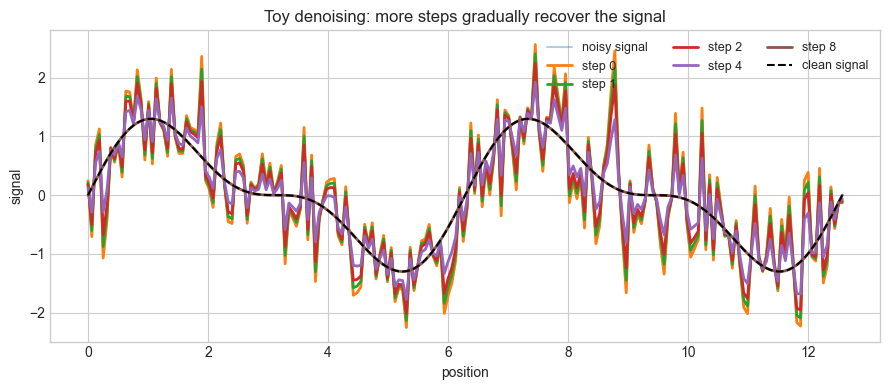

In [29]:
# ------------------------------
# 这段代码做什么：
# 1. 用一条一维曲线模拟原始信号
# 2. 加噪声后，再逐步去噪
# 3. 说明 diffusion step 是“一步步变清楚”
# ------------------------------
rng = np.random.default_rng(SEED)
x = np.linspace(0, 4 * np.pi, 200)
clean = np.sin(x) + 0.5 * np.sin(2 * x)
noise = rng.normal(0, 0.8, size=clean.shape)
noisy = clean + noise

steps = [0, 1, 2, 4, 8]
plt.figure(figsize=(9, 4))
plt.plot(x, noisy, alpha=0.35, label="noisy signal")

for s in steps:
    weight = 1 - s / max(steps)
    recovered = weight * noisy + (1 - weight) * clean
    plt.plot(x, recovered, linewidth=2, label=f"step {s}")

plt.plot(x, clean, color="black", linestyle="--", label="clean signal")
plt.title("Toy denoising: more steps gradually recover the signal")
plt.xlabel("position")
plt.ylabel("signal")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

### step 到底是什么意思？

在扩散模型里，一个 **step** 不是一张图，而是一次去噪迭代。

可以这样理解：

```text
step 0：纯噪声
step 5：只有大概轮廓
step 10：主体开始出现
step 20：细节更稳定
step 40：接近最终图像
```

每一步都会问两个问题：

1. 当前 latent 里哪些部分像噪声？
2. 在文本 prompt 的引导下，下一步应该往哪个方向修？

所以 DiT / diffusion 的核心不是“一次性画出来”，而是“一步步把噪声修成内容”。

In [30]:
# ------------------------------
# 这段代码做什么：
# 1. 计算图片 patch token 数量
# 2. 对比图片和视频的 token 数量
# ------------------------------
def count_patch_tokens(image_size=(512, 512), patch_size=16, frames=1):
    h, w = image_size
    tokens_per_frame = (h // patch_size) * (w // patch_size)
    return tokens_per_frame * frames

configs = [
    ("1 张 512×512 图片", dict(image_size=(512, 512), patch_size=16, frames=1)),
    ("16 帧 512×512 视频", dict(image_size=(512, 512), patch_size=16, frames=16)),
    ("1 张 1024×1024 图片", dict(image_size=(1024, 1024), patch_size=16, frames=1)),
    ("24 帧 1024×1024 视频", dict(image_size=(1024, 1024), patch_size=16, frames=24)),
]

print("配置 | patch token 数量")
print("--- | ---:")
for name, cfg in configs:
    tokens = count_patch_tokens(**cfg)
    print(f"{name} | {tokens:,}")

配置 | patch token 数量
--- | ---:
1 张 512×512 图片 | 1,024
16 帧 512×512 视频 | 16,384
1 张 1024×1024 图片 | 4,096
24 帧 1024×1024 视频 | 98,304


### 为什么视频 token 多很多？

图片主要处理空间 token：

```text
图片 token ≈ H × W / patch_size²
```

视频多了时间维度：

```text
视频 token ≈ T × H × W / patch_size²
```

所以视频不是“多画几张图”那么简单。它还要同时处理：

- 每一帧的视觉质量；
- 前后帧是否连贯；
- 人物身份是否稳定；
- 运动方向是否合理；
- 背景是否闪烁。

这也是为什么视频生成模型通常比图片生成模型更吃算力和显存。

### attention 怎么理解？

attention 做的事情很直观：

> 让每个 token 看看其它 token，然后决定哪些 token 对自己重要。

在图片里：

```text
人脸 token 可以关注眼睛、头发、衣服、背景
```

在视频里：

```text
第 1 帧的人脸 token 可以关注第 20 帧的人脸 token
```

这能帮助模型保持：

- 人物身份；
- 动作连贯；
- 物体位置；
- 背景稳定。

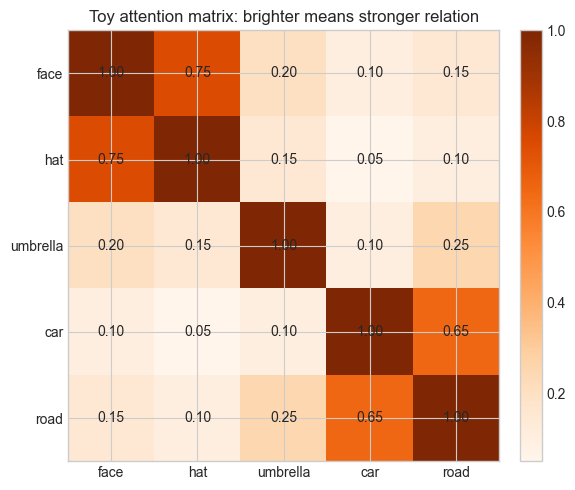

In [31]:
# ------------------------------
# 这段代码做什么：
# 1. 构造一个简化的 attention 矩阵
# 2. 看哪些 token 之间关系更强
# ------------------------------
labels = ["face", "hat", "umbrella", "car", "road"]
attention = np.array([
    [1.00, 0.75, 0.20, 0.10, 0.15],
    [0.75, 1.00, 0.15, 0.05, 0.10],
    [0.20, 0.15, 1.00, 0.10, 0.25],
    [0.10, 0.05, 0.10, 1.00, 0.65],
    [0.15, 0.10, 0.25, 0.65, 1.00],
])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attention, cmap="Oranges")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_title("Toy attention matrix: brighter means stronger relation")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{attention[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 诊断问题：如果 attention 只看局部，会怎样？

如果视频 token 只关注自己附近的 token，而不关注前后帧，就容易出现：

- 人物衣服颜色突然变化；
- 手或脸在运动中变形；
- 背景闪烁；
- 物体位置跳变；
- 镜头运动不自然。

所以视频生成里的 attention 不只是“看清一张图”，还要帮助模型记住：

> **谁是谁、在哪里、怎么动、前后是否一致。**

## Part 8. 拓展：从 CLIP 走到 DiT / Wan 视频生成

前面的内容一直在讲一件事：

```text
图片和文字怎么放到同一个空间里比较？
```

CLIP、ALIGN、SigLIP 的核心都是“比较”：给一张图片和一组文字，算相似度，然后判断哪一个最匹配。

但到了文生图、文生视频，问题变成了另一件事：

```text
能不能根据一段文字，真的生成一张图，甚至生成一段视频？
```

这就进入了扩散模型、DiT 和 Wan 的范围。

---

### 8.1 先分清楚：CLIP 不是生成模型，DiT / Wan 是生成模型

| 问题 | CLIP / ALIGN / SigLIP | DiT / Wan |
|---|---|---|
| 主要目标 | 图文匹配、检索、分类 | 根据条件生成图像或视频 |
| 输入 | 图片 + 文本候选 | 文本 prompt、图片、视频条件等 |
| 输出 | 相似度分数或类别 | 新的图片 / 视频 |
| 核心动作 | 比一比哪个更像 | 一步步把噪声变成内容 |
| 文本的作用 | 作为“标签”或“查询” | 作为生成过程的控制条件 |

一句话区分：

> **CLIP 像是在做“判断题/选择题”；DiT 和 Wan 更像是在“按要求画出来、动起来”。**

---

### 8.2 总桥图：从比较，到生成，再到语言推理

<img src="images/lesson6_multimodal/multimodal_to_generation_bridge.png" width="980">

这张图把本节课后半段的逻辑串起来：

| 阶段 | 核心问题 | 典型模型 | 输出 |
|---|---|---|---|
| 图文匹配 | 图片和文字像不像？ | CLIP / ALIGN / SigLIP | 相似度、排名、类别 |
| 文本控制生成 | 能不能按文字生成？ | DiT / Diffusion / Wan | 图像、视频 |
| 视觉语言推理 | 能不能看图回答问题？ | BLIP-2 / Flamingo / LLaVA | 文本答案、推理 |

课堂一句总结：

> **CLIP 解决“像不像”；DiT / Diffusion 解决“怎么生成”；VLM 解决“怎么回答”。**

---

### 8.3 扩散模型到底在学什么：加噪和去噪

**教学图：正向加噪与反向去噪**

<img src="images/lesson6_multimodal/diffusion_noising_denoising.png" width="980">

扩散模型可以分成两半看：

```text
正向过程：
原图 x0 → 加一点噪声 → 加更多噪声 → 接近纯噪声

反向过程：
纯噪声 → 学着一层层去噪 → 逐渐出现轮廓 → 生成图像
```

可以把扩散模型总结成一句话：

> **正向过程负责“把图毁掉”，反向过程负责“学会把图修回来”。**

课堂追问：

> 如果模型只能看到一张接近纯噪声的图，它凭什么知道下一步应该修成猫、车还是人？

引导大家回答：

- 它不是凭空知道，而是靠训练时见过大量“带噪图像 → 原图”的对应关系。
- 文本 prompt 会告诉模型“往哪个方向修”。
- 每一步 DiT 都在根据当前 latent、时间步和文本条件，预测下一步该怎么去噪。

---

### 8.4 为什么通常在 latent 上生成：VAE + DiT

**教学图：latent diffusion 流程**

<img src="images/lesson6_multimodal/latent_vae_pipeline.png" width="980">

DiT / Stable Diffusion / Wan 通常不是直接在像素上生成，而是在 **latent 空间** 里生成。

为什么？

```text
像素空间：
512 × 512 × 3

latent 空间：
更小、更压缩、语义更集中
```

直接在像素上生成，token 太多，计算和显存压力都很大。压缩到 latent 后，DiT 处理的 token 更少，最后再用 VAE Decoder 解码回图片。

**Wan 论文图：Spatio-temporal VAE / 时空变分自编码器**

<img src="images/lesson6_multimodal/paper_originals/wan_fig8_stvae_section_crop.png" width="980">

这里更适合按 Wan 第 4.1 节的原意来讲：这张图讲的不是“视频重建效果展示”，而是 **Spatio-temporal Variational Autoencoder** 的结构流程。作者先把输入视频编码到更紧凑的 latent 空间，再从 latent 解码回视频，让后面的生成模型不用直接在原始像素帧序列上工作。

原文这一节真正关心的重点，不是单纯“压小”，而是：

> **在提高压缩率的同时，尽量保住重建质量，让空间细节和时间运动信息不要在压缩过程中丢得太厉害。**

从图上可以这样对应理解：

- `Input video`：输入视频；
- `Spat. 2x`：做 2 倍空间压缩；
- `Spat.&Temp. 2x`：同时做 2 倍空间压缩和 2 倍时间压缩；
- `Latent`：得到更紧凑的潜在表示；
- `Output video`：再从 latent 解码回输出视频。

课堂句：

> **Wan 的 VAE 先负责把视频压进 latent，再把 latent 还原回视频；后面的 DiT 则在这个 latent 空间里做生成。**
**Wan Figure 9：Architecture of the Wan**

<img src="images/lesson6_multimodal/paper_originals/wan_fig9_architecture.png" width="980">



这张图把 Wan 的整体流程讲得很清楚：

```text
输入视频 / 图像
   ↓
Wan-Encoder
   ↓
latent 空间
   ↓
N × DiT Blocks 反复去噪
   ↓
Wan-Decoder
   ↓
输出视频
```

同时，文本 prompt 会先进入 `umT5`，再通过 cross attention 影响生成。  
这就是视频生成模型里“文本控制视觉内容”的关键路径。

课堂句：

> **文生图难在“画面好不好”；文生视频难在“画面好不好 + 时间上稳不稳”。**
---

### 8.5 为什么 prompt 能控制生成：classifier-free guidance

**教学图：classifier-free guidance**

<img src="images/lesson6_multimodal/classifier_free_guidance.png" width="980">

扩散模型每一步都要预测噪声。classifier-free guidance 的核心做法是比较两个预测：

```text
无条件预测：
没有 prompt，模型随便生成一个东西。

有条件预测：
带着 prompt，模型按题目生成。
```

然后让生成方向更偏向 prompt：

$$
\epsilon_{\text{cfg}}
=
\epsilon_{\text{nothing}}
+
s \cdot
\left(
\epsilon_{\text{prompt}}
-
\epsilon_{\text{nothing}}
\right)
$$

其中：

- $\epsilon_{\text{nothing}}$：无条件预测；
- $\epsilon_{\text{prompt}}$：有条件预测；
- $s$：guidance scale。

通俗讲：

> 无条件预测像一个自由画家；  
> 有条件预测像一个听 prompt 的画家；  
> guidance 就是老师不断提醒：“再贴近题目一点”。

**Imagen Figure 4：guidance 与 FID**

<img src="images/lesson6_multimodal/paper_originals/imagen_fig4_fidelity_guidance.png" width="980">

Imagen 的结果图里可以看到，guidance、thresholding 等设置会影响生成质量和 FID。  
不要讲成“guidance 越高越好”，更准确的说法是：

| guidance 低 | guidance 高 |
|---|---|
| 更自然 | 更听 prompt |
| 多样性可能更好 | 细节可能更贴近文字 |
| 可能不够贴合题目 | 可能过锐、过饱和、细节失真 |

课堂追问：

> 如果 guidance 太高，模型会不会“听话过头”？

可以引导大家回答：会。过高的 guidance 可能让模型为了贴近 prompt 而牺牲自然度，比如边缘过锐、颜色过饱和、局部纹理不真实。

---

### 8.6 从图片生成到视频生成：为什么更贵？

**教学图：图片 token vs 视频 token**

<img src="images/lesson6_multimodal/video_token_cost.png" width="980">

图片生成主要处理空间 token：

```text
图片：H × W 个 patch token
```

视频生成多了时间维度：

```text
视频：T 帧 × H × W 个 patch token
```

所以视频生成不是“多画几张图”那么简单，而是要同时解决：

- 每一帧好不好看；
- 前后帧是否连贯；
- 人物身份是否稳定；
- 衣服颜色是否跳变；
- 运动方向是否合理；
- 镜头运动是否自然；
- 背景是否闪烁。



---

### 8.7 课堂追问

> 如果视频被切成了很多时空 token，为什么生成 5 秒视频会比生成 1 张图片贵很多？

提示：

- 图片只有空间 token。
- 视频同时有空间 token 和时间 token。
- 帧数越多，token 序列越长。
- Transformer 处理长序列时，计算和显存压力会明显上升。

---

### 参考资料

- DiT 论文：*Scalable Diffusion Models with Transformers*，arXiv:2212.09748  
  https://arxiv.org/abs/2212.09748
- Imagen 论文：*Photorealistic Text-to-Image Diffusion Models with Deep Language Understanding*，arXiv:2205.11487  
  https://arxiv.org/abs/2205.11487
- SD3 论文：*Scaling Rectified Flow Transformers for High-Resolution Image Synthesis*，arXiv:2403.03206  
  https://arxiv.org/abs/2403.03206
- Wan 技术报告：*Wan: Open and Advanced Large-Scale Video Generative Models*，arXiv:2503.20314  
  https://arxiv.org/abs/2503.20314
- Wan2.1 官方代码仓库  
  https://github.com/Wan-Video/Wan2.1

### 8.8 评价视频质量：不能只看“每一帧好不好看”

视频质量至少要看三件事：

| 维度 | 核心问题 | 例子 |
|---|---|---|
| **Fidelity** | 每一帧本身好不好看？ | 光影、纹理、结构是否自然 |
| **Alignment** | 是否听懂 prompt？ | 有没有红车、雨夜街道、人在走路 |
| **Temporal Consistency** | 前后帧是否连贯？ | 人物衣服是否变色、背景是否闪烁 |

所以评价视频生成模型时，不能只问：

```text
这张图像不像真的？
```

还要问：

```text
这段视频是不是像一个连续发生的真实事件？
```

---

### 8.9 常用视频质量指标总览


可以把视频评价指标分成四类：

| 类别 | 指标 / 方法 | 主要看什么 | 局限 |
|---|---|---|---|
| 单帧质量 | FID、IS、LPIPS | 每一帧是否逼真 | 看不出运动是否连贯 |
| 文本对齐 | CLIPScore、Prompt Following | 是否听懂 prompt | 可能忽略细小错误 |
| 时间一致性 | Temporal Consistency、Motion Smoothness | 前后帧是否稳定 | 需要视频级特征或光流 |
| 人类偏好 | MOS、A/B Test、Human Preference | 人是否喜欢 | 成本高，但最直观 |

一句话：

> **图片生成主要评价“像不像”；视频生成还要评价“稳不稳”。**

### 常用图像 / 视频帧质量指标：公式补充

前面我们把视频评价指标分成了四类：单帧质量、文本对齐、时间一致性、人类偏好。这里补充几个常用指标的公式和课堂解释。注意，这些指标大多主要看**单帧质量**或**重建误差**，不能单独说明视频是否连贯。

---

### 1. FID：Fréchet Inception Distance

**FID** 用来衡量：**生成图像分布和真实图像分布是否接近**。

通常做法是：把真实图像和生成图像都送进 Inception 网络，取出高层特征，然后假设这些特征服从高斯分布。

设真实图像特征分布为：

$$\mathcal{N}(\mu_r, \Sigma_r)$$

生成图像特征分布为：

$$\mathcal{N}(\mu_g, \Sigma_g)$$

则 FID 定义为：

$$\text{FID}=\|\mu_r-\mu_g\|_2^2+\text{Tr}\left(\Sigma_r+\Sigma_g-2(\Sigma_r\Sigma_g)^{1/2}\right)$$

其中：

- $\mu_r$：真实图像特征均值；
- $\mu_g$：生成图像特征均值；
- $\Sigma_r$：真实图像特征协方差；
- $\Sigma_g$：生成图像特征协方差；
- $\text{Tr}$：矩阵的迹。

**FID 越低越好。**

课堂解释：

> FID 看的不是某一张图像好不好，而是看生成图像整体分布和真实图像分布像不像。FID 低，说明生成结果在统计分布上更接近真实图像。

局限：

> FID 主要看单帧图像分布，看不出视频前后帧是否连贯。

---

### 2. IS：Inception Score

**Inception Score** 主要看两件事：

1. 每张图是否清晰、可分类；
2. 生成结果整体是否有多样性。

设生成图像为 $x$，Inception 网络输出的类别分布为：

$$p(y|x)$$

所有生成图像的平均类别分布为：

$$p(y)=\mathbb{E}_{x}p(y|x)$$

则 Inception Score 定义为：

$$\text{IS}=\exp\left(\mathbb{E}_{x}D_{\text{KL}}\left(p(y|x)\parallel p(y)\right)\right)$$

其中：

- $p(y|x)$：单张图像被分类成各类别的概率；
- $p(y)$：所有生成图像的平均类别分布；
- $D_{\text{KL}}$：KL 散度。

**IS 越高越好。**

课堂解释：

> 如果每张图都很清晰，模型能很有信心地判断类别，同时所有生成图又不是都集中在同一类，那么 IS 就会比较高。

局限：

> IS 主要适合图像生成，而且偏向 ImageNet 类别判断。它不能判断图像是否听懂 prompt，也不能评价视频时间一致性。

---

### 3. LPIPS：Learned Perceptual Image Patch Similarity

**LPIPS** 用来衡量：**两张图像在人眼感知上像不像**。

它不是直接算像素差，而是把图像送进深度网络，提取多层特征，然后比较特征差异。

设 $x$ 是参考图像，$\hat{x}$ 是生成图像，$\phi_l(x)$ 表示第 $l$ 层提取到的特征，则 LPIPS 可以写成：

$$\text{LPIPS}(x,\hat{x})=\sum_l w_l\frac{1}{H_l W_l}\sum_{h=1}^{H_l}\sum_{w=1}^{W_l}\left\|\phi_l(\hat{x})_{h,w}-\phi_l(x)_{h,w}\right\|_2^2$$

其中：

- $l$：网络层；
- $w_l$：不同层的权重；
- $H_l, W_l$：第 $l$ 层特征图的高和宽；
- $\phi_l(x)$：第 $l$ 层提取到的图像特征。

**LPIPS 越低越好。**

课堂解释：

> LPIPS 不是看像素有没有完全一样，而是看深度特征是否接近。它更接近人眼对图像差异的感受。

局限：

> LPIPS 主要看两张图像之间的感知差异，不能直接判断生成图像是否符合 prompt，也不能评价视频是否连贯。

---

### 4. PSNR：Peak Signal-to-Noise Ratio

**PSNR** 主要用于**有 ground truth 的重建任务**，比如图像重建、视频重建、压缩还原。

设原始图像为 $x$，重建图像为 $\hat{x}$，先计算均方误差：

$$\text{MSE}=\frac{1}{N}\sum_i(x_i-\hat{x}_i)^2$$

其中 $N$ 是像素总数。

PSNR 定义为：

$$\text{PSNR}=20\log_{10}\left(\frac{\text{MAX}_I}{\sqrt{\text{MSE}}}\right)$$

其中：

- $\text{MAX}_I$：像素最大可能值，比如 8-bit 图像通常是 255；
- MSE 越小，PSNR 越高。

**PSNR 越高越好。**

课堂解释：

### PSNR 公式里的 20 和 10 是怎么来的？

这里出现 **10** 和 **20**，是因为 PSNR 用的是信号领域里的 **分贝 dB** 表达方式。分贝的标准定义是：

$$\text{dB}=10\log_{10}\left(\frac{P_1}{P_2}\right)$$

这里用 **10**，是因为分贝本来衡量的是**功率比**，而功率和信号幅值的平方成正比：

$$P \propto A^2$$

套到图像里，\(\text{MAX}_I\) 可以看成像素信号的最大幅值，MSE 是误差的平均功率：

$$\text{MSE}=\mathbb{E}[e^2] \propto P_{\text{noise}}$$

所以信噪比本质上是：

$$\text{SNR}_{\text{power}}=\frac{\text{MAX}_I^2}{\text{MSE}}$$

代入分贝公式：

$$\begin{align*}
\text{PSNR(dB)}
&=10\log_{10}\left(\frac{\text{MAX}_I^2}{\text{MSE}}\right)\\
&=10\log_{10}\left(\left(\frac{\text{MAX}_I}{\sqrt{\text{MSE}}}\right)^2\right)\\
&=20\log_{10}\left(\frac{\text{MAX}_I}{\sqrt{\text{MSE}}}\right)
\end{align*}$$

所以一句话记：

> **底数 10 是分贝的行业标准；系数 20 是因为像素误差是幅值级，而分贝原始公式针对功率，平方项提出来以后变成 \(10\times 2=20\)。**

举个直观例子，8-bit 图像中 \(\text{MAX}_I=255\)，如果 MSE = 25：

$$\text{PSNR}=20\log_{10}\left(\frac{255}{\sqrt{25}}\right)=20\log_{10}(51)\approx 34.15\ \text{dB}$$



> PSNR 看的是重建图像和原始图像之间的像素误差。误差越小，PSNR 越高。

局限：

> PSNR 是像素级指标，和人的主观感受不一定一致。两张图 PSNR 高，不代表人眼看起来一定更自然。

---

### 5. SSIM：Structural Similarity Index

**SSIM** 用来衡量两张图像在**亮度、对比度和结构**上是否相似。

设 $x$ 是参考图像，$\hat{x}$ 是生成或重建图像，SSIM 定义为：

$$\text{SSIM}(x,\hat{x})=\frac{(2\mu_x\mu_{\hat{x}}+C_1)(2\sigma_{x\hat{x}}+C_2)}{(\mu_x^2+\mu_{\hat{x}}^2+C_1)(\sigma_x^2+\sigma_{\hat{x}}^2+C_2)}$$

其中：

- $\mu_x$：图像 $x$ 的亮度均值；
- $\mu_{\hat{x}}$：图像 $\hat{x}$ 的亮度均值；
- $\sigma_x^2$：图像 $x$ 的方差；
- $\sigma_{\hat{x}}^2$：图像 $\hat{x}$ 的方差；
- $\sigma_{x\hat{x}}$：两张图像的协方差；
- $C_1, C_2$：防止分母为 0 的常数。

**SSIM 越高越好。**

课堂解释：

> SSIM 不只是比较像素差，而是比较图像的结构信息，比如亮度、对比度和整体结构是否接近。

局限：

> SSIM 也需要 ground truth，更适合重建任务，不适合直接评价开放式文生图或文生视频。

---

### 课堂总结

这些指标主要解决的是：

> **生成结果在单帧层面像不像真实图像，或者和参考图像像不像。**

但它们不能完整回答：

> **视频是否听懂 prompt？**  
> **前后帧是否连贯？**  
> **人物身份是否稳定？**  
> **运动是否自然？**

所以视频生成评价不能只靠 FID、IS、LPIPS、PSNR、SSIM，还要加上：

- **Alignment**：是否听懂 prompt；
- **Temporal Consistency**：前后帧是否稳定；
- **Motion Smoothness**：运动是否自然；
- **Human Preference**：人是否真的觉得好。

一句话总结：

> **FID、IS、LPIPS、PSNR、SSIM 主要看“像不像”或“重建得像不像”；但视频生成还要额外看“听不听话”和“稳不稳”。**


### 8.10 Fidelity：单帧图像质量

**Fidelity** 主要看每一帧本身是否逼真。

常用指标：

| 指标 | 看什么 | 适合场景 |
|---|---|---|
| **FID** | 生成分布和真实图像分布是否接近 | 图像 / 视频帧质量 |
| **Inception Score, IS** | 清晰度和类别多样性 | 图像生成 |
| **LPIPS** | 感知层面的图像差异 | 图像相似度 |
| **PSNR / SSIM** | 和参考图像相比的重建误差 | 有 ground truth 的重建任务 |

其中 FID 的直觉可以写成：

$$
\text{FID}(p_r, p_g)
=
\|\mu_r - \mu_g\|_2^2
+
\text{Tr}
\left(
\Sigma_r + \Sigma_g
-
2(\Sigma_r \Sigma_g)^{1/2}
\right)
$$

其中：

- $p_r$：真实图像分布；
- $p_g$：生成图像分布；
- $\mu_r, \mu_g$：真实 / 生成特征的均值；
- $\Sigma_r, \Sigma_g$：真实 / 生成特征的协方差；
- $\text{Tr}(\cdot)$：矩阵的迹。

通俗说：

> FID 越小，说明生成图像的整体分布越接近真实图像。

但是注意：

> **FID 低不代表视频一定好。**  
> 因为 FID 主要看单帧分布，不一定能发现闪烁、变形、动作跳变。

### 8.11 Alignment：视频有没有听懂 prompt？

**Alignment** 看生成视频是否和文本 prompt 匹配。

例如 prompt 是：

```text
a red car driving on a rainy street at night
```

一个好的视频应该包含：

- `red car`：有红色车；
- `driving`：车在运动；
- `rainy street`：街道有雨天感；
- `night`：光线是夜晚；
- 多帧之间车和场景保持合理。

课堂版文本 / 视频对齐分数可以写成：

$$
S_{\text{align}}
=
\cos(e_{\text{text}}, e_{\text{video}})
$$

其中：

- $e_{\text{text}}$：文本 prompt 的 embedding；
- $e_{\text{video}}$：视频的 embedding；
- $\cos(\cdot)$：余弦相似度。

如果视频 embedding 来自多帧平均：

$$
e_{\text{video}}
=
\frac{1}{T}
\sum_{t=1}^{T}
e_{\text{frame}}^{(t)}
$$

那么：

$$
S_{\text{align}}
=
\cos
\left(
e_{\text{text}},
\frac{1}{T}
\sum_{t=1}^{T}
e_{\text{frame}}^{(t)}
\right)
$$

这就是 CLIPScore / text-video retrieval 类方法的直觉：  
把文本和视频都变成向量，然后看它们像不像。

局限：

- 可能只看总体语义，忽略细节；
- 可能把“大概像”的视频打高分；
- 对数量、左右关系、文字内容、细粒度属性不够敏感。

### 8.12 Temporal Consistency：视频是否稳定？

**Temporal Consistency** 是视频生成最重要的额外指标。

它主要检查：

- 前后帧是否闪烁；
- 人物身份是否稳定；
- 衣服颜色是否跳变；
- 物体是否突然消失；
- 运动轨迹是否合理；
- 背景是否抖动或变形。

一个简单的时间一致性分数可以写成相邻帧相似度：

$$
Q_{\text{temp}}
=
\frac{1}{T-1}
\sum_{t=1}^{T-1}
\cos(e_t, e_{t+1})
$$

其中：

- $T$：视频帧数；
- $e_t$：第 $t$ 帧的视频 / 图像特征；
- $\cos(e_t, e_{t+1})$：相邻帧相似度。

这个分数越高，说明相邻帧越接近。

但是要注意：

> 相邻帧太相似也不一定好。

如果模型只让相邻帧完全一样，视频会非常稳定，但没有运动：

$$
e_t = e_{t+1}
\quad \Rightarrow \quad
Q_{\text{temp}} = 1
$$

这会导致视频像一张静态图片。  
所以时间一致性不是“每一帧越像越好”，而是：

> **主体和背景要稳定，动作和运动要自然。**

### 8.13 Motion Quality：运动是否自然？

视频不只是“稳定”，还要有合理运动。

例如 prompt 是：

```text
a person is walking through a park
```

好视频应该满足：

- 人的位置逐渐变化；
- 腿部动作连续；
- 背景有合理的视差；
- 人物身份和衣服颜色稳定。

可以用光流（optical flow）来描述相邻帧之间的运动：

$$
F_t(x, y)
=
(u_t(x, y), v_t(x, y))
$$

其中：

- $F_t$：第 $t$ 帧到第 $t+1$ 帧的光流；
- $(x, y)$：像素位置；
- $u_t, v_t$：水平和垂直方向的运动。

课堂直觉：

```text
光流 = 每个像素点下一帧往哪里动
```

如果光流太乱，视频会出现：

- 背景抖动；
- 人物变形；
- 物体瞬移；
- 运动方向不合理。

所以视频评价里经常同时看两个东西：

| 指标 | 希望 |
|---|---|
| Temporal Consistency | 主体稳定，不闪烁 |
| Motion Quality | 动作自然，不僵硬 |

一句话：

> **好的视频不是完全不动，而是“该稳定的稳定，该运动的地方自然运动”。**

### 8.14 Human Preference：人到底觉得好不好？

很多视频质量问题很难完全用公式衡量，所以常用人工评价。

常见方法：

| 方法 | 怎么做 | 优点 | 局限 |
|---|---|---|---|
| **MOS, Mean Opinion Score** | 人给视频打分 | 直观 | 成本高 |
| **A/B Test** | 两个模型结果二选一 | 容易比较 | 样本要足够 |
| **Expert Review** | 专家按多个维度打分 | 细 | 慢 |
| **Human Preference** | 人选择更喜欢的视频 | 接近真实体验 | 不一定解释原因 |

常见人工打分维度：

- 画面逼真度；
- prompt 匹配度；
- 时间一致性；
- 运动自然度；
- 主体身份稳定性；
- 背景稳定性；
- 是否有伪影、变形、闪烁；
- 整体审美质量。

一个简单的人类偏好概率可以写成：

$$
P(A \succ B)
=
\sigma(s_A - s_B)
$$

其中：

- $A, B$：两个生成视频；
- $s_A, s_B$：它们的人类偏好分数；
- $\sigma$：sigmoid 函数；
- $P(A \succ B)$：人更喜欢 A 而不是 B 的概率。

课堂解释：

> 人类偏好不是“不科学”，而是很多审美和自然度问题目前仍然需要人来判断。

### 3 分钟复述任务

请不用看笔记，用下面 6 个词串起本节课主线：

```text
embedding
similarity
prompt
latent
token
attention
```

建议句式：

> CLIP 把图片和文字变成 **embedding**，用 **similarity** 做匹配；  
> prompt 决定文本条件；  
> 生成模型在 **latent** 空间里工作；  
> DiT 把 latent 切成 **token**；  
> attention 让 token 互相协调，最终生成图片或视频。

## Part 9. 课堂小测：10 个问题检查有没有听懂

1. zero-shot 图像分类，在 CLIP 里本质上是在比较什么？
2. 一个 4x4 图文相似度矩阵里，对角线通常代表什么？
3. 为什么 `a photo of a cat` 和 `cat` 可能得到不同结果？
4. CLIP 为什么适合做“多选题”，但不适合直接自由生成一段回答？
5. ALIGN 的数据很噪声，为什么仍然可能训练出有用表示？
6. SigLIP 相比普通 softmax 对比学习，想解决什么训练问题？
7. CLIPText 和 T5 encoder 在文生图模型里分别像什么角色？
8. DiT / Wan 里，`latent`、`token`、`attention` 分别解决什么问题？
9. 生成模型评价里，`alignment` 和 `fidelity` 分别看什么？
10. 为什么视频生成不能只看单帧图像质量，还要看 temporal consistency？

参考答案方向：

- 不背定义，先说“图像向量和文本向量谁更接近”。
- 遇到架构图，先找输入、桥接模块、输出。
- 遇到效果图，先问“作者想证明模型会什么”。
- 遇到公式，先问“它在奖励什么、惩罚什么”。
- 遇到生成模型，同时问“听懂 prompt 了吗”和“画面本身好吗”。
- 遇到视频生成，还要问“前后帧是否连贯、运动是否自然”。

## Part 10. 小结：10 句话收住全课

1. 多模态模型的核心目标，是把不同模态映射到同一个语义空间里。
2. CLIP 通过图文对比学习，让图像和文本的相似度变成了可直接使用的推理信号。
3. zero-shot 分类，本质上是“图像 vs 一组文本提示词”的相似度比较。
4. 图文检索和多选式问答，本质上也是跨模态排序。
5. prompt 模板会影响文本表示，所以 prompt engineering 会影响 zero-shot 效果。
6. CLIP 很强，但它更像匹配器；遇到计数、细粒度关系、复杂推理时要小心。
7. T5 编码器主要提供“提示词到底说了什么”的细粒度语言条件。
8. DiT / Wan 把文本条件、latent、token 和 attention 接起来，让模型一步步生成图像或视频。
9. 视频生成评价不能只看单帧质量，还要看 temporal consistency 和 motion quality。
10. 好的生成模型要同时兼顾 alignment、fidelity、稳定性、运动自然度和人类偏好。

### 课后继续追问

- 如果 toy CLIP 只在有限模板上训练，它的泛化会卡在哪？
- 为什么 CLIP 能做多选式 VQA，却不擅长自由生成答案？
- 如果一个文生图模型去掉 T5，只保留 CLIP，哪些 prompt 最可能先出问题？
- ImageBind 如果继续往前走，和现代 VLM / 多模态大模型之间是什么关系？
- 为什么视频生成比图片生成更吃 token、attention、算力和显存？
- 如果一个视频时间一致性很高，但完全不动，它算好视频吗？

## Part 11. 课程作业：用 OpenCLIP 在 Flickr8k 上训练图文匹配模型

### 1. 作业目标

本次作业要求你使用 OpenCLIP 官方开源代码，在公开数据集 Flickr8k 上训练一个最小 CLIP 图文匹配模型。

你要验证的不是“模型多强”，而是完整走通 CLIP 训练流程：

```text
图片 + caption
    ↓
image encoder + text encoder
    ↓
图文相似度矩阵
    ↓
contrastive loss
    ↓
image-to-text retrieval / text-to-image retrieval
```

这和本节课的核心问题直接相关：

> CLIP 为什么要求正确图文对在对角线上更亮，错误图文对更暗？

---

### 2. 数据集

公开数据集：

- Hugging Face：[clip-benchmark/wds_flickr8k](https://huggingface.co/datasets/clip-benchmark/wds_flickr8k)
- 原始 OpenCLIP 项目：<https://github.com/mlfoundations/open_clip>

本 notebook 配套已下载的数据放在：

```text
data/flickr8k_wds/
```

其中：

```text
data/flickr8k_wds/train/0.tar
data/flickr8k_wds/train/1.tar
data/flickr8k_wds/train/2.tar
data/flickr8k_wds/train/3.tar

data/flickr8k_wds/test/0.tar
data/flickr8k_wds/test/1.tar
data/flickr8k_wds/test/2.tar
data/flickr8k_wds/test/3.tar
data/flickr8k_wds/test/4.tar
```

Flickr8k 的特点是：

- 每张图片有英文 caption；
- 数据规模适中，适合课程作业；
- 天然适合做 image-to-text / text-to-image retrieval；
- 可以直接用 OpenCLIP 的 webdataset 训练入口。

---

### 3. 数据集样例：训练集

下面展示训练集中的 16 张图片和对应 caption：

<img src="images/lesson6_multimodal/flickr8k_train_samples.png" width="980">

观察重点：

- 图片内容和 caption 是否匹配？
- caption 是完整句子，而不是固定类别标签；
- 训练时，模型要学习“这张图”和“这句话”之间的语义对应关系。

---

### 4. 数据集样例：测试集

下面展示测试集中的 16 张图片和对应 caption：

<img src="images/lesson6_multimodal/flickr8k_val_samples.png" width="980">

观察重点：

- 测试集图片和训练集图片不同；
- 但 caption 仍然是自然语言描述；
- 训练完成后，可以用测试集评估 retrieval 效果。

---

### 5. 模型

课程作业使用：

```text
model = RN50
pretrained = openai
```

含义：

- `RN50`：ResNet-50 作为 image encoder；
- `openai`：加载 OpenAI CLIP 的预训练权重；
- 训练任务：在 Flickr8k 上继续做图文对比学习。

本作业不要求从零训练 CLIP，而是 fine-tune 一个已有 CLIP 模型，让它适应 Flickr8k 的图文匹配任务。

---

### 6. 训练代码

训练入口使用 OpenCLIP 官方代码：

```bash
python -m open_clip_train.main
```


```

如果你在 4090 上跑，建议使用完整 Flickr8k，参考代码如下：

```bash
PYTHONPATH=open_clip/src python -m open_clip_train.main \
  --train-data 'data/flickr8k_wds/train/{0..3}.tar' \
  --val-data 'data/flickr8k_wds/test/{0..4}.tar' \
  --dataset-type webdataset \
  --train-num-samples 29000 \
  --val-num-samples 1000 \
  --model RN50 \
  --pretrained openai \
  --batch-size 16 \
  --epochs 3 \
  --workers 4 \
  --lr 5e-5 \
  --warmup 0 \
  --logs open_clip_logs \
  --name flickr8k_rn50_openai_4090 \
  --precision amp \
  --save-frequency 1 \
  --zeroshot-frequency 1 \
  --log-every-n-steps 20 \
  --device cuda \
  --force-image-size 224
```

如果显存不够，把：

```bash
--batch-size 16
```

改成：

```bash
--batch-size 8
```

---

### 7. 本地验证结果

我已经在本地 CPU 上跑了一个最小 smoke run：

```text
train samples: 128
val samples:   64
epochs:        1
model:         RN50
pretrained:    openai
```

最终训练日志：

```text
Train Epoch: 0 [128/128 (100%)] ...
Contrastive_loss: 2.0211
Loss: 2.0211
```

验证集 retrieval 指标：

| 指标 | 结果 |
|---|---:|
| image-to-text mean rank | 17.43 |
| image-to-text median rank | 7.00 |
| image-to-text R@1 | 21.50% |
| image-to-text R@5 | 44.50% |
| image-to-text R@10 | 59.50% |
| text-to-image mean rank | 26.44 |
| text-to-image median rank | 16.00 |
| text-to-image R@1 | 6.00% |
| text-to-image R@5 | 29.50% |
| text-to-image R@10 | 41.50% |
| validation clip loss | 0.2580 |

注意：这个结果只是证明代码和数据集能跑通，不是最终性能。  
正式作业建议用完整 Flickr8k、GPU、至少 3 个 epoch。

---

### 8. 你需要提交什么

请提交一个简短报告，包含以下内容：

1. **训练命令**  
   写清楚你使用的数据路径、模型、batch size、epoch、learning rate、precision、device。

2. **训练日志截图或关键日志**  
   至少包含：
   - 最后几个 batch 的 `Contrastive_loss`；
   - `Eval Epoch` 的 retrieval 指标。

3. **loss 曲线或 loss 表格**  
   可以手绘，也可以从日志中整理成表格。

4. **retrieval 结果**  
   至少展示 3 个例子：
   - 给定一句话，检索 top-5 图片；
   - 给定一张图，检索 top-5 caption。

5. **错误分析**  
   至少分析 2 个检索错误：
   - 模型为什么可能选错？
   - 是图片太相似、caption 太短，还是模型没有学到关键属性？

---



### 10. 加分项

可以选做一个或多个：

1. **对比训练前后 retrieval 效果**  
   比较 `pretrained=openai` 和 fine-tune 后的 R@1 / R@5 / R@10。

2. **换模型**  
   尝试 `ViT-B-32` 或其他 OpenCLIP 模型，比较训练时间和检索效果。

3. **换数据规模**  
   比较只用 1 个 tar 和用全部 Flickr8k 的差异。

4. **分析 caption 长度**  
   长 caption 是否更容易被模型利用？短 caption 是否更容易混淆？

5. **可视化相似度矩阵**  
   选一个 mini-batch，画出 image-text similarity matrix，说明对角线是否更亮。

---

### 11. 和本节课的关系

这个作业对应本节课的三个核心概念：

1. **共享表示空间**  
   图片和文字都被编码成向量。

2. **对比学习目标**  
   正确图文对要靠近，错误图文对要远离。

3. **检索任务**  
   给定文本找图片，或给定图片找文本，本质都是相似度排序。

最后请用一句话总结你的实验：

> 我的模型是否学会了“图文谁和谁更匹配”？证据是什么？


---

### 数据下载说明：不要把 `data/flickr8k_wds/` 上传到 Git

`data/flickr8k_wds/` 是 Flickr8k webdataset 的本地缓存目录，大小约 **956 MB**，不建议上传到 GitHub。
作业提交时只需要提交 notebook、代码、日志摘要和结果截图，不需要提交数据文件。

公开下载链接：

- 数据集主页：<https://huggingface.co/datasets/clip-benchmark/wds_flickr8k>
- OpenCLIP 官方代码：<https://github.com/mlfoundations/open_clip>

建议把下面路径加入 `.gitignore`：

```gitignore
data/
open_clip_logs/
open_clip_training_smoke_data/
```

如果本地还没有数据，可以在 notebook 里运行下面的下载代码。下载完成后，训练命令中的路径仍然是：

```text
data/flickr8k_wds/train/{0..3}.tar
data/flickr8k_wds/test/{0..4}.tar
```

In [ ]:
# --------------------------------------------------------------
# 可选：下载公开 Flickr8k webdataset
# 说明：
# - 数据约 956 MB，不建议上传到 Git。
# - 下载后用于 OpenCLIP 训练命令：
#   data/flickr8k_wds/train/{0..3}.tar
#   data/flickr8k_wds/test/{0..4}.tar
# --------------------------------------------------------------
from pathlib import Path
from huggingface_hub import hf_hub_download

files = [
    ("train", "train/0.tar"),
    ("train", "train/1.tar"),
    ("train", "train/2.tar"),
    ("train", "train/3.tar"),
    ("test", "test/0.tar"),
    ("test", "test/1.tar"),
    ("test", "test/2.tar"),
    ("test", "test/3.tar"),
    ("test", "test/4.tar"),
]

repo_id = "clip-benchmark/wds_flickr8k"
local_dir = Path("data/flickr8k_wds")

for split, filename in files:
    path = hf_hub_download(
        repo_id=repo_id,
        repo_type="dataset",
        filename=filename,
        local_dir=str(local_dir),
    )
    print(f"downloaded: {path}")

print("Flickr8k webdataset is ready under:", local_dir)